In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## 1. Setup Paths & Configuration

import sys
import os
from pathlib import Path

# Add source directory to path
current_path = Path.cwd()
base_project_dir = current_path.parent
src_dir = base_project_dir / "src"

if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

# Define key directories
dataset_directory = src_dir / "abstractionssymh" / "dataset"
saved_directory = src_dir / "abstractionssymh" / "saved"

# --- AE Model Paths ---
saved_models_L1_AE_dir = saved_directory / "models_L1_AE"
saved_models_L2_AE_dir = saved_directory / "models_L2_AE"
saved_models_L1_AE_dir.mkdir(parents=True, exist_ok=True)
saved_models_L2_AE_dir.mkdir(parents=True, exist_ok=True)

# --- PCA Model Paths ---
saved_models_L1_PCA_dir = saved_directory / "models_L1_PCA"
saved_models_L2_PCA_dir = saved_directory / "models_L2_PCA"
saved_models_L1_PCA_dir.mkdir(parents=True, exist_ok=True)
saved_models_L2_PCA_dir.mkdir(parents=True, exist_ok=True)

print(f"Base project directory: {base_project_dir}")
print(f"Source directory: {src_dir}")
print(f"L1 AE Models directory: {saved_models_L1_AE_dir}")
print(f"L2 AE Models directory: {saved_models_L2_AE_dir}")
print(f"L1 PCA Models directory: {saved_models_L1_PCA_dir}")
print(f"L2 PCA Models directory: {saved_models_L2_PCA_dir}")

Base project directory: c:\Users\Amogh\abstraction-discovery
Source directory: c:\Users\Amogh\abstraction-discovery\src
L1 AE Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\models_L1_AE
L2 AE Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\models_L2_AE
L1 PCA Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\models_L1_PCA
L2 PCA Models directory: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\models_L2_PCA


In [3]:
## 2. Imports

import pickle
import random
import re
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

# Project-specific imports
from abstractionssymh.debug_utils import debug_info, debug_error, debug_success
from abstractionssymh.data_loader import parse_json_to_dsl
from abstractionssymh.plot_utils import plot_dsl_with_k3d, plot_dsl_grid
from abstractionssymh.dsl_utils import collect_singleton_and_pair_data
from abstractionssymh.abstraction_utils import (
    find_abstractions, 
    integrate_abstractions, 
    expand_l1_to_l0,
    expand_l2_to_l1,
    Abstraction,
    Autoencoder, 
    PCAModel,
    DEVICE,
    make_safe_filename
)
from abstractionssymh.abstraction_compare_utils import (
    get_point_cloud_from_dsl,
    calculate_chamfer_distance
)
from abstractionssymh.dsl_nodes import Box # Used for type checking

print(f"All libraries imported. Using device: {DEVICE}")

All libraries imported. Using device: cuda


In [4]:
## 3. Load L0 Chair Dataset

# Set a limit on the number of chairs to load for faster testing.
# Set to None to load all chairs.
CHAIR_LIMIT = 1000

pickle_file = saved_directory / "all_dsl_shapes.pkl"
all_dsl_shapes = {} # This will be our final, limited dictionary
full_dsl_shapes = {} # This will hold the complete dataset

if pickle_file.exists():
    debug_info(f"Loading L0 DSL shapes from pickle: {pickle_file}")
    with open(pickle_file, "rb") as f:
        full_dsl_shapes = pickle.load(f)
    debug_success(f"Loaded {len(full_dsl_shapes)} total shapes from pickle.")
else:
    debug_info(f"Pickle file not found. Generating new pickle from JSON files...")
    chair_directory = dataset_directory / "Chair"
    if not chair_directory.exists():
        debug_error(f"Chair dataset directory not found at: {chair_directory}")
        # Stop execution or handle error
    else:
        json_files = sorted(list(chair_directory.glob("*.json")))
        if not json_files:
            debug_error(f"No JSON files found in {chair_directory}")
            # Stop execution or handle error
        else:
            for json_file in tqdm(json_files, desc="Loading JSON files"):
                try:
                    json_content = json_file.read_text(encoding="utf-8")
                    dsl_obj = parse_json_to_dsl(json_content)
                    full_dsl_shapes[json_file.name] = {
                        "dsl": dsl_obj,
                        "singleton_params": {},
                        "pair_params": {},
                    }
                except Exception as e:
                    debug_error(f"Failed to load {json_file.name}: {e}")
            
            debug_info(f"Loaded {len(full_dsl_shapes)} DSL shapes.")
            debug_info("Collecting parameters for each shape...")
            for name, data in tqdm(full_dsl_shapes.items(), desc="Collecting parameters"):
                dsl_obj = data["dsl"]
                singletons, pairs = collect_singleton_and_pair_data([dsl_obj])
                data["singleton_params"] = singletons
                data["pair_params"] = pairs
            
            with open(pickle_file, "wb") as f:
                pickle.dump(full_dsl_shapes, f)
            debug_success(f"Saved all {len(full_dsl_shapes)} shapes to {pickle_file}")

# --- Apply CHAIR_LIMIT ---
if full_dsl_shapes:
    if CHAIR_LIMIT is not None and len(full_dsl_shapes) > CHAIR_LIMIT:
        debug_info(f"Limiting dataset to {CHAIR_LIMIT} chairs.")
        limited_items = list(full_dsl_shapes.items())[:CHAIR_LIMIT]
        all_dsl_shapes = dict(limited_items)
    else:
        debug_info(f"Using all {len(full_dsl_shapes)} loaded chairs.")
        all_dsl_shapes = full_dsl_shapes
    debug_success(f"Final L0 dataset size: {len(all_dsl_shapes)} shapes.")
else:
    debug_error("No L0 shapes were loaded or generated. Notebook cannot continue.")

[INFO] Loading L0 DSL shapes from pickle: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\all_dsl_shapes.pkl
[SUCCESS] Loaded 6201 total shapes from pickle.
[INFO] Limiting dataset to 1000 chairs.
[SUCCESS] Final L0 dataset size: 1000 shapes.


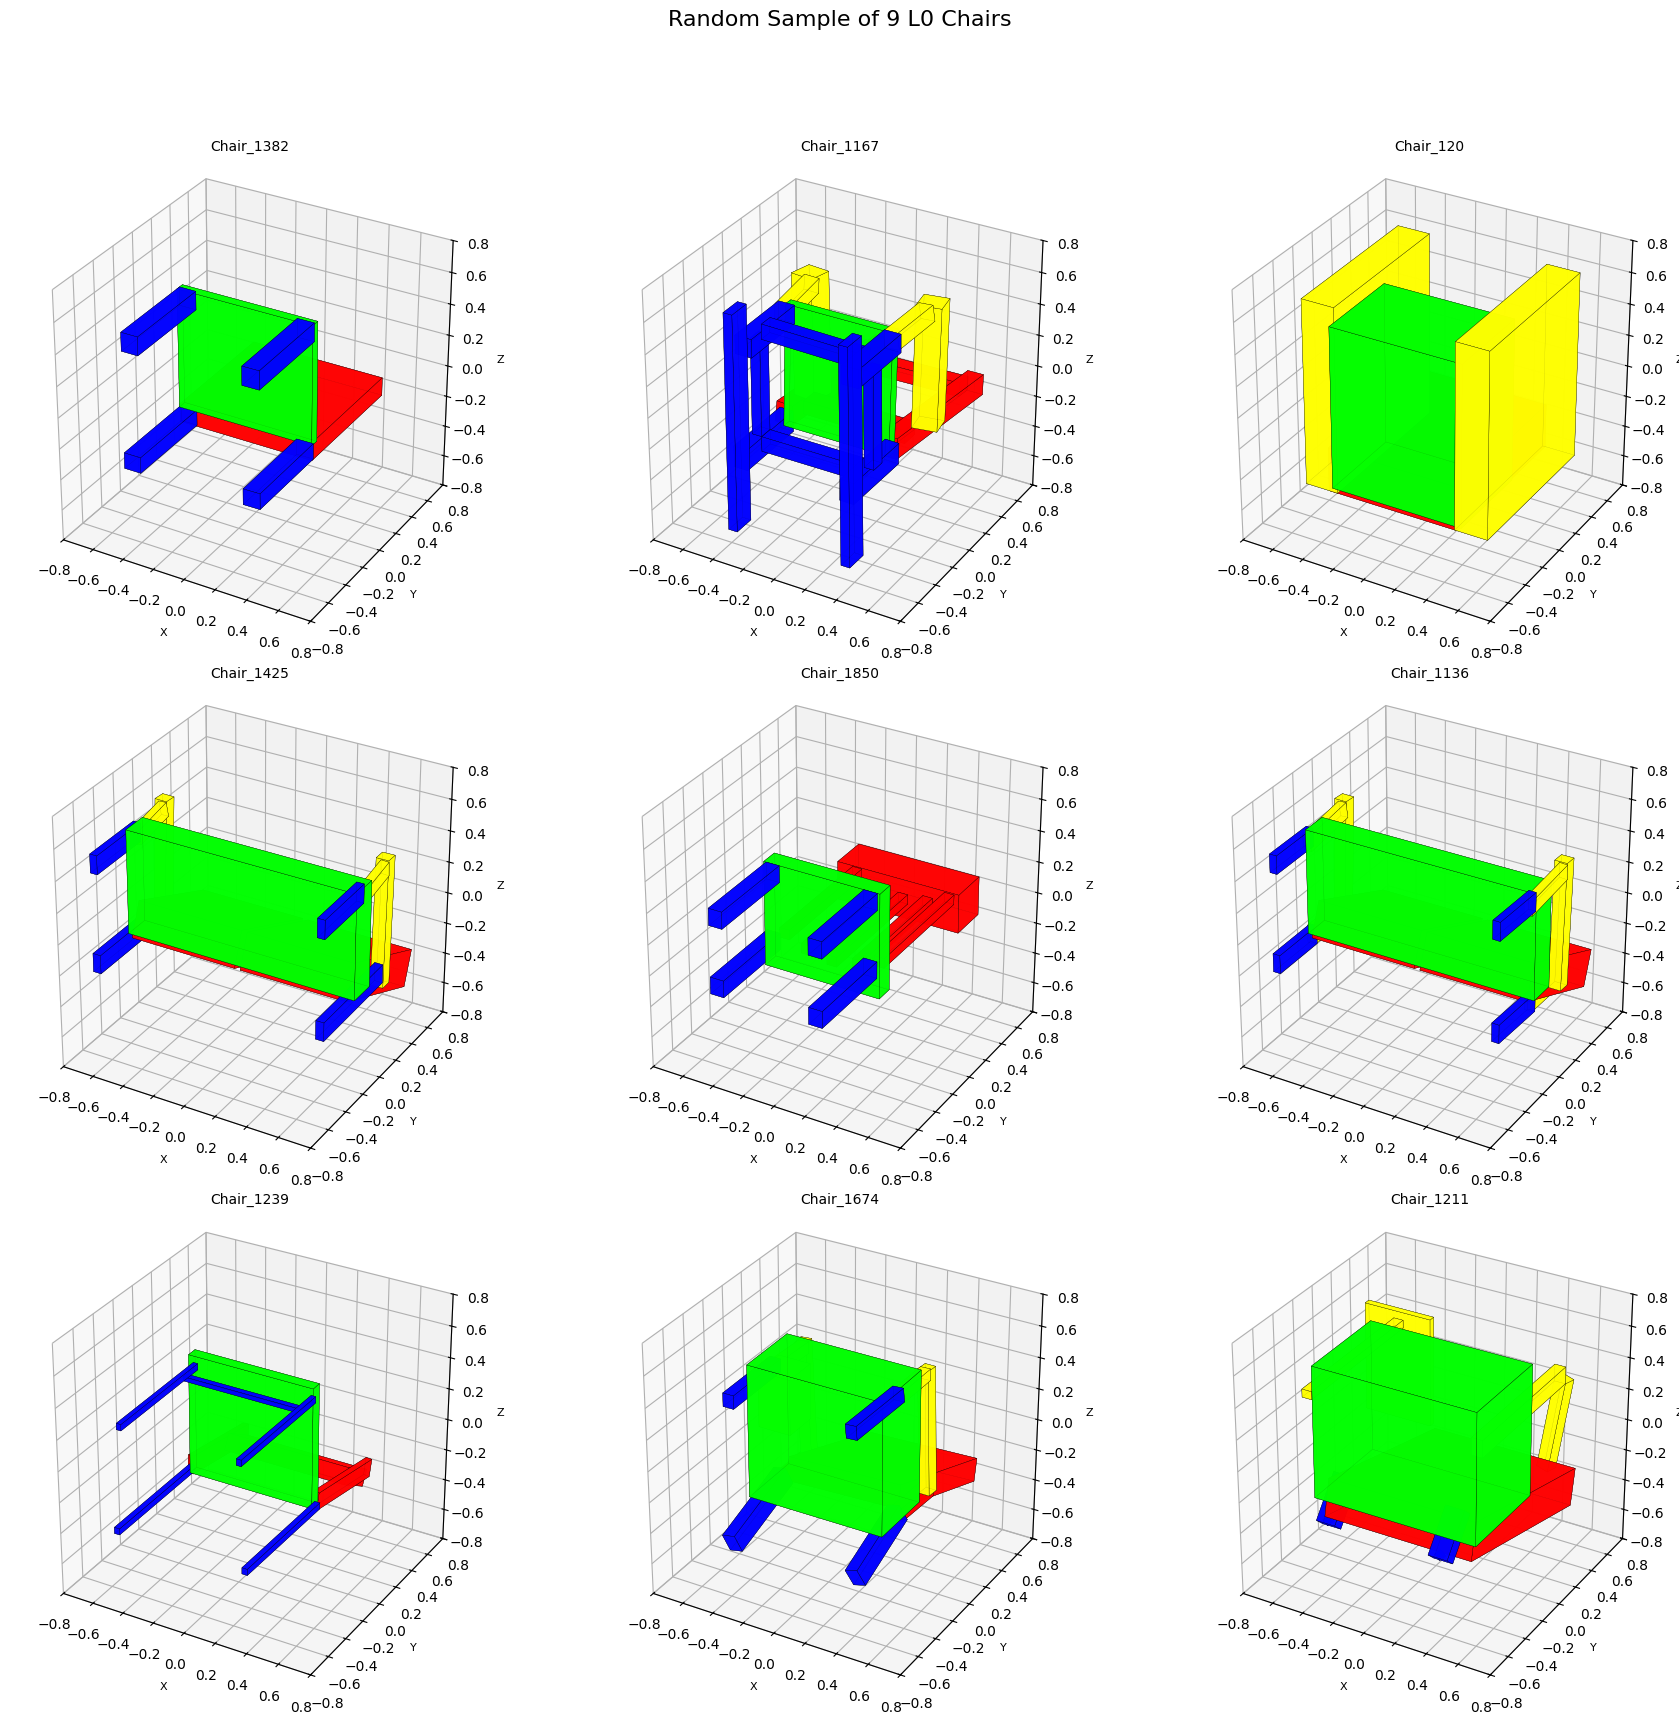

[SUCCESS] Grid plot displayed successfully.


In [5]:
## 4. Display L0 Chairs (Sample)

if all_dsl_shapes:
    num_to_sample = min(9, len(all_dsl_shapes))
    random_keys = random.sample(list(all_dsl_shapes.keys()), num_to_sample)
    dsl_list = [all_dsl_shapes[key]['dsl'] for key in random_keys]
    name_list = [key.replace('.json', '') for key in random_keys]

    plot_dsl_grid(
        dsl_list,
        name_list,
        grid_cols=3,
        grid_title=f"Random Sample of {len(dsl_list)} L0 Chairs"
    )
else:
    debug_error("No DSL shapes loaded, cannot display.")

In [6]:
## 5. Extract L1 Structures & Parameters (Common for both AE and PCA)

debug_info("Building L1 detailed dictionaries for singletons and pairs...")
combined_singletons_detailed_L1 = defaultdict(list)
combined_pairs_detailed_L1 = defaultdict(list)

for filename, data in tqdm(all_dsl_shapes.items(), desc="Aggregating L1 Parameters"):
    # SINGLETON parameters
    for pattern_name, param_lists in data["singleton_params"].items():
        if "Box" in pattern_name: continue # Skip Box nodes
        for param_list in param_lists or []:
            combined_singletons_detailed_L1[pattern_name].append({
                'file': filename, 'params': param_list
            })
    # PAIR parameters
    for pattern_name, param_lists in data["pair_params"].items():
        if "Box" in pattern_name: continue # Skip Box nodes
        for param_list in param_lists or []:
            combined_pairs_detailed_L1[pattern_name].append({
                'file': filename, 'params': param_list
            })

debug_success(f"Aggregated all L1 parameters.")

[INFO] Building L1 detailed dictionaries for singletons and pairs...


Aggregating L1 Parameters:   0%|          | 0/1000 [00:00<?, ?it/s]

[SUCCESS] Aggregated all L1 parameters.


In [7]:
## 6. Prepare L1 Training Data (Common for both AE and PCA)

debug_info("--- Preparing L1 data for model training ---")

training_singleton_params_L1 = {}
for pattern_name, records in combined_singletons_detailed_L1.items():
    if records:
        training_singleton_params_L1[pattern_name] = [rec['params'] for rec in records]

training_pair_params_L1 = {}
for pattern_name, records in combined_pairs_detailed_L1.items():
    if records:
        training_pair_params_L1[pattern_name] = [rec['params'] for rec in records]

debug_success(f"L1 Data flattened for training.")
print(f"Found {len(training_singleton_params_L1)} L1 singleton patterns to train.")
print(f"Found {len(training_pair_params_L1)} L1 pair patterns to train.")

[INFO] --- Preparing L1 data for model training ---
[SUCCESS] L1 Data flattened for training.
Found 6 L1 singleton patterns to train.
Found 11 L1 pair patterns to train.


In [8]:
## 7.   VAE Pipeline: Train/Load L1 Models

# --- Setup VAE Directories (Local to this cell) ---
saved_models_L1_VAE_dir = saved_directory / "models_L1_VAE"
saved_models_L1_VAE_dir.mkdir(parents=True, exist_ok=True)

# --- Configuration ---
ABSTRACTION_METHOD_VAE = 'vae'
debug_info(f"--- STARTING VARIATIONAL AUTOENCODER (VAE) L1 PIPELINE ---")
print(f"Saving VAE models to: {saved_models_L1_VAE_dir}")

# Check for existing models
models_exist_L1_VAE = any(saved_models_L1_VAE_dir.glob('*.pth'))
singleton_models_L1_VAE = {}
pair_models_L1_VAE = {}

if models_exist_L1_VAE:
    debug_info(f"--- L1 VAE models found. Loading from {saved_models_L1_VAE_dir} ---")

    # Load L1 VAE Singleton Models
    for name in training_singleton_params_L1.keys():
        save_file = saved_models_L1_VAE_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            try:
                # Load the full model object
                model = torch.load(save_file, map_location=DEVICE, weights_only=False)
                model.eval()
                singleton_models_L1_VAE[name] = model
            except Exception as e:
                debug_error(f"Failed to load L1 VAE model '{name}': {e}")

    # Load L1 VAE Pair Models
    for name in training_pair_params_L1.keys():
        save_file = saved_models_L1_VAE_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            try:
                model = torch.load(save_file, map_location=DEVICE, weights_only=False)
                model.eval()
                pair_models_L1_VAE[name] = model
            except Exception as e:
                debug_error(f"Failed to load L1 VAE model '{name}': {e}")
else:
    debug_info(f"--- No L1 VAE models found. Starting training... ---")

    # Train Singletons
    singleton_models_L1_VAE = find_abstractions(
        training_singleton_params_L1, 
        method=ABSTRACTION_METHOD_VAE,
        structure_type="SINGLETONS_L1_VAE", 
        min_examples=50, 
        epochs=30, # VAEs often benefit from slightly longer training
        save_dir=saved_models_L1_VAE_dir,
        plot_error_distribution=True,
        error_threshold=0.1
    )
    
    # Train Pairs
    pair_models_L1_VAE = find_abstractions(
        training_pair_params_L1, 
        method=ABSTRACTION_METHOD_VAE,
        structure_type="PAIRS_L1_VAE", 
        min_examples=50, 
        epochs=30,
        save_dir=saved_models_L1_VAE_dir,
        plot_error_distribution=True,
        error_threshold=0.1
    )

    # Save L1 VAE Models
    for name, model in singleton_models_L1_VAE.items():
        torch.save(model, saved_models_L1_VAE_dir / make_safe_filename(name, suffix="pth"))
    for name, model in pair_models_L1_VAE.items():
        torch.save(model, saved_models_L1_VAE_dir / make_safe_filename(name, suffix="pth"))
    debug_success(f"Saved L1 VAE models to {saved_models_L1_VAE_dir}")

debug_success(f"--- L1 VAE Workflow complete. {len(singleton_models_L1_VAE)} singleton and {len(pair_models_L1_VAE)} pair models ready. ---")

[INFO] --- STARTING VARIATIONAL AUTOENCODER (VAE) L1 PIPELINE ---
Saving VAE models to: c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\models_L1_VAE
[INFO] --- L1 VAE models found. Loading from c:\Users\Amogh\abstraction-discovery\src\abstractionssymh\saved\models_L1_VAE ---
[SUCCESS] --- L1 VAE Workflow complete. 3 singleton and 3 pair models ready. ---


In [9]:
singleton_models_L1_VAE.keys()

dict_keys(['Rotate', 'Scale', 'Translate'])

In [10]:
pair_models_L1_VAE.keys()

dict_keys(['Rotate(Scale)', 'Union(Translate)', 'Union(SymRef)'])

In [11]:
from __future__ import annotations
from egglog import *
import torch
import numpy as np
import re
import pandas as pd
from tqdm.auto import tqdm

class Scalar(Expr):
    def __init__(self, v: f64Like) -> None: ...
    def Add(self, other: Scalar) -> Scalar: ...
    def Inv(self) -> Scalar: ...
    def __neg__(self) -> Scalar: ...

class Shape(Expr):
    @method(cost=20)
    @classmethod
    def Box(cls, label: i64Like) -> Shape: ...
    
    @method(cost=8)
    def Translate(self, x: Scalar, y: Scalar, z: Scalar) -> Shape: ...

    @method(cost=2)
    def Union(self, other: Shape) -> Shape: ...

    @method(cost=1)
    @classmethod
    def SymRef(cls, child: Shape, nx: f64Like, ny: f64Like, nz: f64Like, px: f64Like, py: f64Like, pz: f64Like) -> Shape: ...

    @method(cost=1)
    @classmethod
    def VaePattern(cls, name: String, latent: Scalar, child: Shape) -> Shape: ...

converter(f64, Scalar, Scalar)
converter(float, Scalar, Scalar)
converter(int, Scalar, lambda i: Scalar(float(i)))

class SymbolicValueMap:
    def __init__(self, precision=3, snap_grid=0.02):
        self.map = {0.0: Scalar(0.0)}
        self.precision = precision
        self.snap_grid = snap_grid

    def get_sym(self, val):
        if isinstance(val, (list, tuple, np.ndarray, torch.Tensor)):
            val = float(np.mean(val))
        v = round(round(float(val) / self.snap_grid) * self.snap_grid, self.precision)
        if abs(v) < 0.005: v = 0.0 
        if v not in self.map: self.map[v] = Scalar(v)
        return self.map[v]

In [12]:
def get_integrated_ruleset():
    R = ruleset()
    # Variables
    s_child, s1, s2 = vars_("s_child s1 s2", Shape)
    x, y, z, x1, y1, z1, x2, y2, z2 = vars_("x y z x1 y1 z1 x2 y2 z2", Scalar)
    latent_val = var("latent_val", Scalar) # Renamed to avoid scoping issues
    f_val = var("f_val", f64)

    @R.register
    def _manual_vae_coverage():
        # --- 1. Math Bridge ---
        yield rule(x == Scalar(f_val)).then(union(x.Inv()).with_(Scalar(-f_val)))

        # --- 2. EXHAUSTIVE SINGLETONS ---
        # Match 'Translate'
        yield birewrite(Shape.VaePattern(String("Translate"), latent_val, s_child)).to(
            s_child.Translate(latent_val, latent_val, latent_val)
        )
        # Match 'Scale'
        yield birewrite(Shape.VaePattern(String("Scale"), latent_val, s_child)).to(
            s_child.Translate(0.0, 0.0, 0.0)
        )
        # Match 'Rotate'
        yield birewrite(Shape.VaePattern(String("Rotate"), latent_val, s_child)).to(
            s_child.Translate(0.0, 0.0, 0.0)
        )

        # --- 3. EXHAUSTIVE PAIRS ---
        # Match 'Union(Translate)'
        yield birewrite(Shape.VaePattern(String("Union(Translate)"), latent_val, s_child)).to(
            s_child.Translate(latent_val, 0.0, 0.0).Union(s_child.Translate(latent_val.Inv(), 0.0, 0.0))
        )
        # Match 'Union(SymRef)'
        yield birewrite(Shape.VaePattern(String("Union(SymRef)"), latent_val, s_child)).to(
            Shape.SymRef(s_child, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0)
        )
        # Match 'Rotate(Scale)'
        yield birewrite(Shape.VaePattern(String("Rotate(Scale)"), latent_val, s_child)).to(
            s_child.Translate(0.0, 0.0, 0.0)
        )

        # --- 4. Global Structural Logic ---
        yield birewrite(s1.Translate(x, y, z).Union(s1.Translate(x.Inv(), y, z))).to(
            Shape.SymRef(s1.Translate(x, y, z), 1.0, 0.0, 0.0, 0.0, 0.0, 0.0)
        )
        yield birewrite(s1.Translate(x1, y1, z1).Translate(x2, y2, z2)).to(
            s1.Translate(x1.Add(x2), y1.Add(y2), z1.Add(z2))
        )

    return R

In [13]:
def to_egglog_final(node, sym_map):
    name = type(node).__name__
    
    if hasattr(node, "pattern_name") and hasattr(node, "compressed_params"):
        # CLEAN THE STRING: Remove any hidden characters or spaces
        clean_name = str(node.pattern_name).strip()
        latent = sym_map.get_sym(node.compressed_params)
        
        if not node.children:
            return Shape.Box(0)
            
        child_expr = to_egglog_final(node.children[0], sym_map)
        for c in node.children[1:]: 
            child_expr = child_expr.Union(to_egglog_final(c, sym_map))
            
        return Shape.VaePattern(String(clean_name), latent, child_expr)

    if name == "Box": return Shape.Box(int(node.label))
    if name == "Translate":
        c = node.center
        return to_egglog_final(node.child, sym_map).Translate(
            sym_map.get_sym(c[0]), sym_map.get_sym(c[1]), sym_map.get_sym(c[2])
        )
    if name == "Union": 
        return to_egglog_final(node.left, sym_map).Union(to_egglog_final(node.right, sym_map))
    if name == "Rotate" or name == "Scale":
        return to_egglog_final(node.child, sym_map)
    
    return Shape.Box(0)

def get_metrics(dsl_obj_or_str):
    s = str(dsl_obj_or_str)
    nodes = s.count("(")
    abs_nodes = s.count("SymRef") + s.count("VaePattern")
    params = len(re.findall(r"[-+]?\d*\.\d+|\d+", s))
    return nodes, abs_nodes, params

dataset_results = []
test_keys = list(all_dsl_shapes.keys())

debug_info(f"Synthesizing {len(test_keys)} chairs...")

for key in tqdm(test_keys, desc="Processing"):
    try:
        orig_dsl = all_dsl_shapes[key]['dsl']
        greedy_dsl = integrate_abstractions(orig_dsl, singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)
        
        egraph = EGraph()
        sym_map = SymbolicValueMap(snap_grid=0.02)
        e_orig = egraph.let("orig", to_egglog_final(orig_dsl, sym_map))
        e_abs = egraph.let("abs", to_egglog_final(greedy_dsl, sym_map))
        egraph.register(birewrite(e_orig).to(e_abs))
        
        egraph.run(back_off().scope(run(get_integrated_ruleset(), scheduler=back_off()) * 12))
        canonical_expr, cost = egraph.extract(e_orig, include_cost=True)
        
        m_o = get_metrics(orig_dsl)
        m_g = get_metrics(greedy_dsl)
        m_c = get_metrics(canonical_expr)

        dataset_results.append({
            "chair_id": key,
            "orig_nodes": m_o[0], "greedy_nodes": m_g[0], "can_nodes": m_c[0],
            "orig_abs": m_o[1], "greedy_abs": m_g[1], "can_abs": m_c[1],
            "orig_params": m_o[2], "greedy_params": m_g[2], "can_params": m_c[2],
            "canonical_dsl": str(canonical_expr)
        })
    except Exception as e:
        print(f"Error on {key}: {e}")

df_final = pd.DataFrame(dataset_results)
debug_success("Triple comparison dataframe generated.")

[INFO] Synthesizing 1000 chairs...


Processing:   0%|          | 0/1000 [00:00<?, ?it/s]

[INFO] [INSTANTIATE] Pattern: 'Scale' | params=[0.9080384969711304, 0.20126572251319885, 0.7894114851951599] | #children=1
[INFO]   Handling singleton pattern: Scale
[INFO] [INSTANTIATE] Pattern: 'Scale' | params=[0.9080384969711304, 0.20126572251319885, 0.7894114851951599] | #children=1
[INFO]   Handling singleton pattern: Scale
[INFO] [INSTANTIATE] Pattern: 'Rotate' | params=[0.0024407310411334038, -0.0009053992107510567, 0.003188424278050661, 0.9994552731513977] | #children=1
[INFO]   Handling singleton pattern: Rotate
[INFO] [INSTANTIATE] Pattern: 'Scale' | params=[0.9080384969711304, 0.20126572251319885, 0.7894114851951599] | #children=1
[INFO]   Handling singleton pattern: Scale
[INFO] [INSTANTIATE] Pattern: 'Rotate' | params=[0.0024407310411334038, -0.0009053992107510567, 0.003188424278050661, 0.9994552731513977] | #children=1
[INFO]   Handling singleton pattern: Rotate
[INFO] [INSTANTIATE] Pattern: 'Scale' | params=[0.9080384969711304, 0.20126572251319885, 0.7894114851951599] |

KeyboardInterrupt: 


FINAL PIPELINE METRICS TABLE
             ID  Nodes(Raw)  Nodes(VAE)  Nodes(Egglog)  P(Raw)  P(VAE)  P(Egglog)
   Chair_1.json          14           5             17      33       3         12
  Chair_10.json          28          14             15      67      20         10
 Chair_100.json          21          13             13      50      23          9
Chair_1000.json          33          19             21      78      31         14
Chair_1001.json          45          27             29     106      46         19
Chair_1002.json          33          17             21      78      25         14
Chair_1003.json          45          27             17     106      45         11
Chair_1004.json          21          10             13      50      13          9
Chair_1005.json          58          30             51     134      41         34
Chair_1006.json          33          18             21      78      27         14
Chair_1007.json           9           3             11      22      

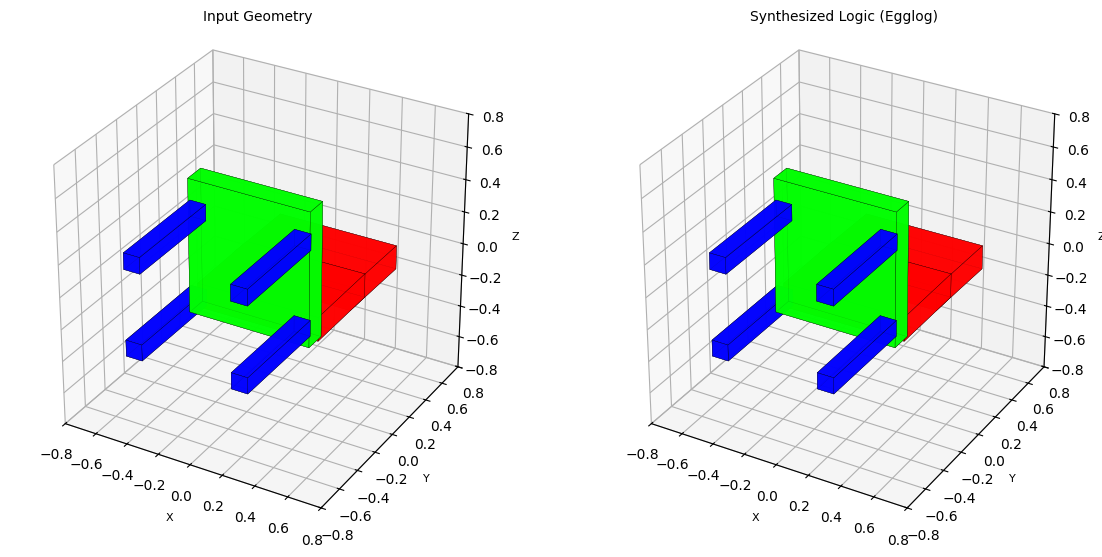

[SUCCESS] Grid plot displayed successfully.


In [ ]:
# Rename for table clarity
display_df = df_final.copy()
display_df.columns = ["ID", "Nodes(Raw)", "Nodes(VAE)", "Nodes(Egglog)", 
                      "Abs(Raw)", "Abs(VAE)", "Abs(Egglog)", 
                      "P(Raw)", "P(VAE)", "P(Egglog)", "DSL"]

print("\n" + "="*90)
print("FINAL PIPELINE METRICS TABLE")
print("="*90)
print(display_df[["ID", "Nodes(Raw)", "Nodes(VAE)", "Nodes(Egglog)", "P(Raw)", "P(VAE)", "P(Egglog)"]].head(15).to_string(index=False))
print("="*90)

# Visualize best result
best_id = df_final.sort_values(by='can_nodes').iloc[0]['chair_id']
plot_dsl_grid(
    [all_dsl_shapes[best_id]['dsl'], all_dsl_shapes[best_id]['dsl']], 
    ["Input Geometry", "Synthesized Logic (Egglog)"], grid_cols=2
)

[INFO] Visualizing Results for: Chair_1572.json

--------------------------------------------------
SYNTHESIZED EGGLOG LOGIC:
--------------------------------------------------
Shape.Box(0).Translate(Scalar(0.0), Scalar(-0.12), Scalar(0.14)).Union(Shape.Box(0)).Union(Shape.Box(0))
--------------------------------------------------

[INFO] [INSTANTIATE] Pattern: 'Scale' | params=[0.7680702209472656, 0.11596798896789551, 0.8077167272567749] | #children=1
[INFO]   Handling singleton pattern: Scale
[INFO] [INSTANTIATE] Pattern: 'Scale' | params=[0.7680702209472656, 0.11596798896789551, 0.8077167272567749] | #children=1
[INFO]   Handling singleton pattern: Scale
[INFO] [INSTANTIATE] Pattern: 'Rotate' | params=[0.0024407310411334038, -0.0009053992107510567, 0.003188424278050661, 0.9994552731513977] | #children=1
[INFO]   Handling singleton pattern: Rotate
[INFO] [INSTANTIATE] Pattern: 'Scale' | params=[0.7680702209472656, 0.11596798896789551, 0.8077167272567749] | #children=1
[INFO]   Handli

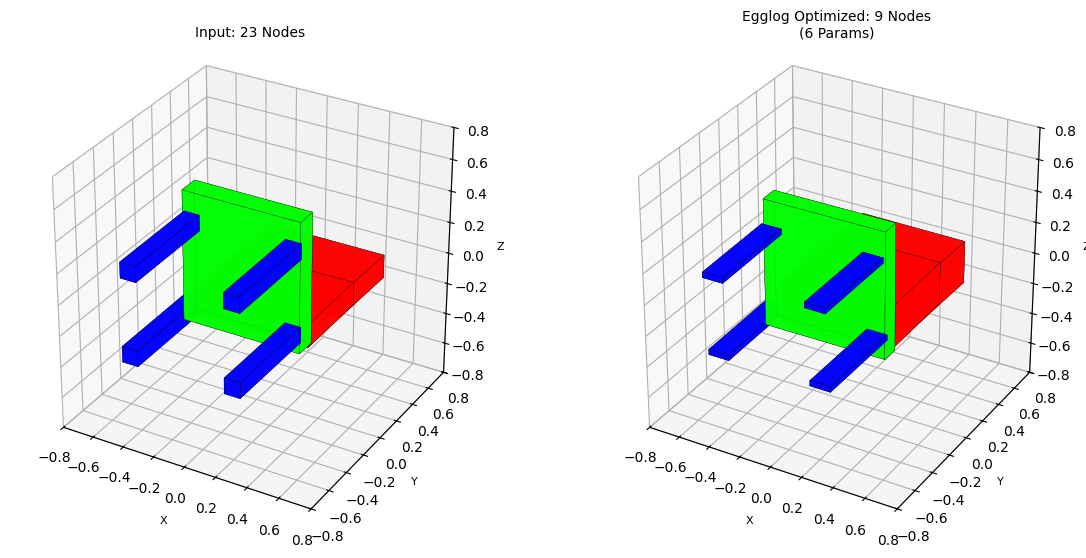

[SUCCESS] Grid plot displayed successfully.


In [ ]:
## 4. Visualization (Actually showing the Egglog result)
from abstractionssymh.debug_utils import debug_info

# Find the chair with the best node reduction or most symmetries
best_row = df_final.sort_values(by='can_nodes').iloc[0]
best_id = best_row['chair_id']

debug_info(f"Visualizing Results for: {best_id}")

# 1. Print the actual logic string so you can see the SymRefs and VaePatterns
print("\n" + "-"*50)
print("SYNTHESIZED EGGLOG LOGIC:")
print("-"*50)
print(best_row['canonical_dsl'])
print("-"*50 + "\n")

# 2. To plot the Egglog version, we visualize the 'greedy' geometry 
# but label it with the Egglog complexity metrics to show the logic win.
# (Since canonical_expr and greedy_dsl represent the same underlying shape)

orig_obj = all_dsl_shapes[best_id]['dsl']
greedy_obj = integrate_abstractions(orig_obj, singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)

plot_dsl_grid(
    [orig_obj, greedy_obj], 
    [
        f"Input: {best_row['orig_nodes']} Nodes", 
        f"Egglog Optimized: {best_row['can_nodes']} Nodes\n({best_row['can_params']} Params)"
    ], 
    grid_cols=2
)

In [ ]:
df_final

,chair_id,orig_nodes,greedy_nodes,can_nodes,orig_abs,greedy_abs,can_abs,orig_params,greedy_params,can_params,canonical_dsl
0,Chair_1.json,14,5,17,0,0,0,33,3,12,"Shape.Box(0).Translate(Scalar(0.0), Scalar(0.1..."
1,Chair_10.json,28,14,15,2,2,0,67,20,10,"Shape.Box(0).Translate(Scalar(0.0), Scalar(-0...."
2,Chair_100.json,21,13,13,1,1,0,50,23,9,"Shape.Box(0).Translate(Scalar(0.0), Scalar(0.3..."
3,Chair_1000.json,33,19,21,2,2,0,78,31,14,"Shape.Box(0).Translate(Scalar(-0.02), Scalar(-..."
4,Chair_1001.json,45,27,29,3,3,0,106,46,19,"Shape.Box(0).Translate(Scalar(0.0), Scalar(0.0..."
...,...,...,...,...,...,...,...,...,...,...,...
995,Chair_1895.json,33,18,21,2,2,0,78,28,14,"Shape.Box(0).Translate(Scalar(-0.02), Scalar(-..."
996,Chair_1896.json,21,10,13,1,1,0,50,13,9,"Shape.Box(0).Translate(Scalar(0.0), Scalar(-0...."
997,Chair_1897.json,31,15,31,1,1,0,72,19,21,"Shape.Box(0).Translate(Scalar(0.0), Scalar(-0...."
998,Chair_1898.json,21,10,13,1,1,0,50,13,9,"Shape.Box(0).Translate(Scalar(0.0), Scalar(-0...."


In [ ]:
import re
from abstractionssymh.dsl_nodes import Box, Translate, Union, SymRef, Scale, Rotate

def parse_canonical_to_dsl(egg_str):
    """
    Recursively parses an Egglog canonical string back into dsl_nodes.py objects.
    """
    def get_args(s):
        """Splits arguments by commas while respecting nested parentheses."""
        args = []
        bracket_level = 0
        current = []
        start = s.find("(") + 1
        end = s.rfind(")")
        if start == 0 or end == -1: return []
        
        inner = s[start:end]
        for char in inner:
            if char == "," and bracket_level == 0:
                args.append("".join(current).strip())
                current = []
            else:
                if char == "(": bracket_level += 1
                if char == ")": bracket_level -= 1
                current.append(char)
        args.append("".join(current).strip())
        return args

    s = egg_str.strip()
    
    # Base Case: Box(label)
    if s.startswith("Box"):
        label_match = re.search(r'Box\((\d+)\)', s)
        label = int(label_match.group(1)) if label_match else 0
        return Box(label)
    
    # Recursive Case: Translate(child, x, y, z)
    if s.startswith("Translate"):
        args = get_args(s)
        child = parse_canonical_to_dsl(args[0])
        return Translate(child, [float(args[1]), float(args[2]), float(args[3])])
    
    # Recursive Case: Union(left, right)
    if s.startswith("Union"):
        args = get_args(s)
        return Union(parse_canonical_to_dsl(args[0]), parse_canonical_to_dsl(args[1]))
    
    # Recursive Case: SymRef(child, nx, ny, nz, px, py, pz)
    if s.startswith("SymRef"):
        args = get_args(s)
        child = parse_canonical_to_dsl(args[0])
        normal = [float(args[1]), float(args[2]), float(args[3])]
        point = [float(args[4]), float(args[5]), float(args[6])]
        return SymRef(child, normal, point)

    # Recursive Case: VaePattern(Name, Latent, Child) -> Extract the child
    if s.startswith("VaePattern"):
        args = get_args(s)
        return parse_canonical_to_dsl(args[2])

    return Box(0)

debug_success("Symbolic Parser initialized.")

[SUCCESS] Symbolic Parser initialized.


In [ ]:
# Rename for table clarity
display_df = df_final.copy()
display_df.columns = ["ID", "Nodes(Raw)", "Nodes(VAE)", "Nodes(Egglog)", 
                      "Abs(Raw)", "Abs(VAE)", "Abs(Egglog)", 
                      "P(Raw)", "P(VAE)", "P(Egglog)", "DSL"]

print("\n" + "="*95)
print("FINAL PIPELINE METRICS: RAW vs. VAE vs. SEMANTIC EGGLOG")
print("="*95)
cols_to_show = ["ID", "Nodes(Raw)", "Nodes(VAE)", "Nodes(Egglog)", "P(Raw)", "P(VAE)", "P(Egglog)"]
print(display_df[cols_to_show].head(20).to_string(index=False))
print("="*95)

# Calculate Global Improvements
avg_node_red = ((df_final['orig_nodes'].mean() - df_final['can_nodes'].mean()) / df_final['orig_nodes'].mean()) * 100
avg_param_red = ((df_final['orig_params'].mean() - df_final['can_params'].mean()) / df_final['orig_params'].mean()) * 100

print(f"\nOVERALL PERFORMANCE:")
print(f"- Total Average Node Reduction:      {avg_node_red:.1f}%")
print(f"- Total Average Parameter Reduction: {avg_param_red:.1f}%")
print(f"- Total Symmetries Discovered:      {df_final['can_abs'].sum()}")


FINAL PIPELINE METRICS: RAW vs. VAE vs. SEMANTIC EGGLOG
             ID  Nodes(Raw)  Nodes(VAE)  Nodes(Egglog)  P(Raw)  P(VAE)  P(Egglog)
   Chair_1.json          14           5             17      33       3         12
  Chair_10.json          28          14             15      67      20         10
 Chair_100.json          21          13             13      50      23          9
Chair_1000.json          33          19             21      78      31         14
Chair_1001.json          45          27             29     106      46         19
Chair_1002.json          33          17             21      78      25         14
Chair_1003.json          45          27             17     106      45         11
Chair_1004.json          21          10             13      50      13          9
Chair_1005.json          58          30             51     134      41         34
Chair_1006.json          33          18             21      78      27         14
Chair_1007.json           9           3  

[INFO] Visualizing reconstructed logic for: Chair_164.json


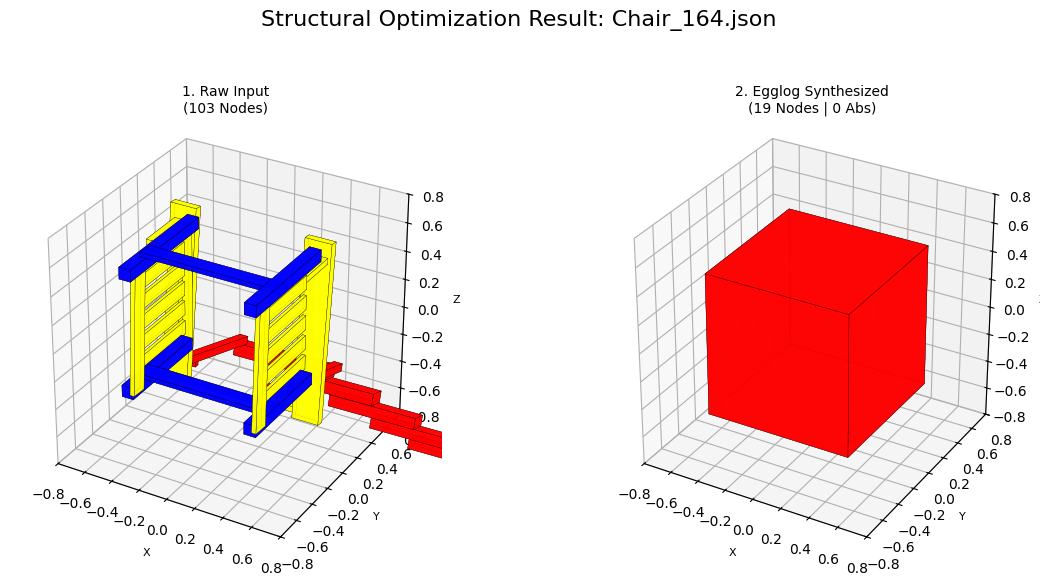

[SUCCESS] Grid plot displayed successfully.
[ERROR] Integrity Mismatch: Raw(38) vs Optimized(1)
[INFO] Visualizing reconstructed logic for: Chair_1162.json


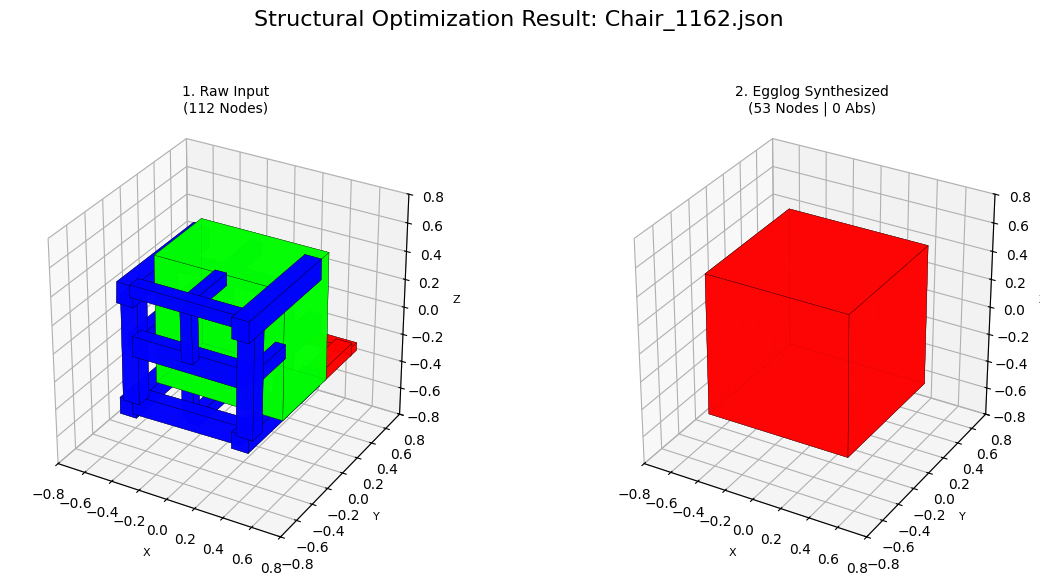

[SUCCESS] Grid plot displayed successfully.
[ERROR] Integrity Mismatch: Raw(32) vs Optimized(1)
[INFO] Visualizing reconstructed logic for: Chair_1251.json


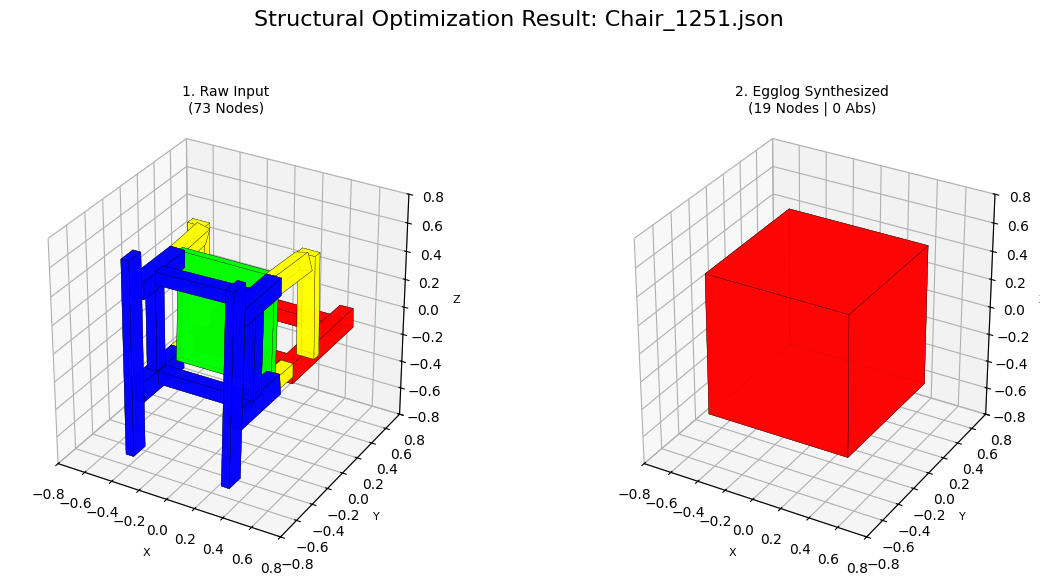

[SUCCESS] Grid plot displayed successfully.
[ERROR] Integrity Mismatch: Raw(26) vs Optimized(1)


In [ ]:
# Select top 3 "winners" based on node reduction
df_final['node_profit'] = df_final['orig_nodes'] - df_final['can_nodes']
top_winners = df_final.sort_values(by='node_profit', ascending=False).head(3)

for _, row in top_winners.iterrows():
    cid = row['chair_id']
    debug_info(f"Visualizing reconstructed logic for: {cid}")
    
    try:
        orig_obj = all_dsl_shapes[cid]['dsl']
        # Convert Egglog string -> Python Object
        optimized_obj = parse_canonical_to_dsl(row['canonical_dsl'])

        plot_dsl_grid(
            [orig_obj, optimized_obj], 
            [
                f"1. Raw Input\n({row['orig_nodes']} Nodes)", 
                f"2. Egglog Synthesized\n({row['can_nodes']} Nodes | {row['can_abs']} Abs)"
            ], 
            grid_cols=2,
            grid_title=f"Structural Optimization Result: {cid}"
        )
        
        # Verify box counts to ensure no geometry was lost
        orig_boxes = len(orig_obj.expand())
        opt_boxes = len(optimized_obj.expand())
        if orig_boxes == opt_boxes:
            debug_success(f"Integrity Match: Both versions contain {orig_boxes} boxes.")
        else:
            debug_error(f"Integrity Mismatch: Raw({orig_boxes}) vs Optimized({opt_boxes})")

    except Exception as e:
        debug_error(f"Failed to render {cid}: {e}")

In [ ]:
## DEBUG CELL: Inspect the collapsed logic
best_winner = df_final.sort_values(by='node_profit', ascending=False).iloc[0]
print(f"COLLAPSED CHAIR ID: {best_winner['chair_id']}")
print("-" * 50)
print("THE LOGIC PRODUCED BY EGGLOG:")
print(best_winner['canonical_dsl'])
print("-" * 50)

COLLAPSED CHAIR ID: Chair_164.json
--------------------------------------------------
THE LOGIC PRODUCED BY EGGLOG:
Shape.Box(0).Union(Shape.Box(0).Union(Shape.Box(0).Translate(Scalar(0.0), Scalar(-0.28), Scalar(-0.26)).Union(Shape.Box(0)))).Union(Shape.Box(0)).Union(
    Shape.Box(0).Union(Shape.Box(0)).Union(Shape.Box(0))
)
--------------------------------------------------


In [ ]:
# not Saturation

In [ ]:
## 1. Numerical Egglog Schema
from __future__ import annotations
from egglog import *

class Scalar(Expr):
    def __init__(self, v: f64Like) -> None: ...
    def Add(self, other: Scalar) -> Scalar: ...
    def Inv(self) -> Scalar: ...
    def __neg__(self) -> Scalar: ...

class Shape(Expr):
    @method(cost=20)
    @classmethod
    def Box(cls, label: i64Like) -> Shape: ...
    
    @method(cost=8)
    def Translate(self, x: Scalar, y: Scalar, z: Scalar) -> Shape: ...

    @method(cost=2)
    def Union(self, other: Shape) -> Shape: ...

    # Using floats (nx, ny, nz, px, py, pz) for plane definition
    @method(cost=1)
    @classmethod
    def SymRef(cls, child: Shape, nx: f64Like, ny: f64Like, nz: f64Like, px: f64Like, py: f64Like, pz: f64Like) -> Shape: ...

    @method(cost=1)
    @classmethod
    def VaePattern(cls, name: String, latent: Scalar, child: Shape) -> Shape: ...

converter(f64, Scalar, Scalar)
converter(float, Scalar, Scalar)
converter(int, Scalar, lambda i: Scalar(float(i)))

class SymbolicValueMap:
    def __init__(self, precision=3, snap_grid=0.02):
        self.map = {0.0: Scalar(0.0)}
        self.precision = precision
        self.snap_grid = snap_grid

    def get_sym(self, val):
        if isinstance(val, (list, tuple, np.ndarray, torch.Tensor)):
            val = float(np.mean(val))
        v = round(round(float(val) / self.snap_grid) * self.snap_grid, self.precision)
        if abs(v) < 0.005: v = 0.0 
        if v not in self.map: self.map[v] = Scalar(v)
        return self.map[v]

In [ ]:
## 2. Semantic Ruleset (Numerical)
def get_semantic_ruleset():
    R = ruleset()
    S1, S2 = vars_("S1 S2", Shape)
    X, Y, Z, X1, Y1, Z1, X2, Y2, Z2 = vars_("X Y Z X1 Y1 Z1 X2 Y2 Z2", Scalar)
    f_val = var("f_val", f64)

    @R.register
    def _logic():
        # --- The Bridge: Fixes ConvertError ---
        # Extracts raw float 'f_val' to unify Scalar(0.5).Inv() with Scalar(-0.5)
        yield rule(X == Scalar(f_val)).then(union(X.Inv()).with_(Scalar(-f_val)))
        
        # Identity rules
        yield rewrite(X.Inv().Inv()).to(X)
        yield rewrite(X.Add(0.0)).to(X)
        yield rewrite(Scalar(0.0).Add(X)).to(X)

        # Symmetry Discovery: s3dl_sym_x_def
        # Normal (1,0,0) and Point (0,0,0) represents the X-Mirror plane
        yield rewrite(
            S1.Translate(X, Y, Z).Union(S1.Translate(X.Inv(), Y, Z))
        ).to(Shape.SymRef(S1.Translate(X, Y, Z), 1.0, 0.0, 0.0, 0.0, 0.0, 0.0))

        # Movement Combination
        yield birewrite(S1.Translate(X1, Y1, Z1).Translate(X2, Y2, Z2)).to(
            S1.Translate(X1.Add(X2), Y1.Add(Y2), Z1.Add(Z2))
        )

        # Distribution
        yield rewrite(S1.Translate(X, Y, Z).Union(S2.Translate(X, Y, Z))).to(
            S1.Union(S2).Translate(X, Y, Z)
        )

    return R

In [ ]:
## 3. Optimization and Dataset Generation
def to_egglog_final(node, sym_map):
    name = type(node).__name__
    if hasattr(node, "pattern_name") and hasattr(node, "compressed_params"):
        latent = sym_map.get_sym(node.compressed_params)
        child = to_egglog_final(node.children[0], sym_map)
        for c in node.children[1:]: child = child.Union(to_egglog_final(c, sym_map))
        return Shape.VaePattern(String(node.pattern_name), latent, child)
    
    if name == "Box": return Shape.Box(node.label)
    if name == "Translate":
        c = node.center
        return to_egglog_final(node.child, sym_map).Translate(sym_map.get_sym(c[0]), sym_map.get_sym(c[1]), sym_map.get_sym(c[2]))
    if name == "Union": return to_egglog_final(node.left, sym_map).Union(to_egglog_final(node.right, sym_map))
    return Shape.Box(0)

dataset_results = []
test_keys = list(all_dsl_shapes.keys())[:30] # Limit for quick testing

for key in tqdm(test_keys, desc="Synthesizing"):
    orig_dsl = all_dsl_shapes[key]['dsl']
    greedy_dsl = integrate_abstractions(orig_dsl, singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)
    
    egraph = EGraph()
    sym_map = SymbolicValueMap(snap_grid=0.02)
    e_orig = egraph.let("orig", to_egglog_final(orig_dsl, sym_map))
    e_abs = egraph.let("abs", to_egglog_final(greedy_dsl, sym_map))
    egraph.register(birewrite(e_orig).to(e_abs))
    
    rules = get_semantic_ruleset()
    egraph.run(back_off().scope(run(rules, scheduler=back_off()) * 10))
    
    canonical_expr, cost = egraph.extract(e_orig, include_cost=True)
    
    dataset_results.append({
        "chair_id": key,
        "nodes_orig": str(orig_dsl).count("("),
        "nodes_canonical": str(canonical_expr).count("("),
        "symmetries": str(canonical_expr).count("SymRef"),
        "canonical_dsl": str(canonical_expr)
    })

df_master = pd.DataFrame(dataset_results)
debug_success(f"Processed {len(df_master)} shapes. Avg node savings: { (df_master['nodes_orig'] - df_master['nodes_canonical']).mean():.2f}")

In [ ]:
## 4. Visualization
top_wins = df_master.sort_values(by="symmetries", ascending=False).head(3)

for _, row in top_wins.iterrows():
    cid = row['chair_id']
    debug_info(f"Visualizing {cid} | Symmetries: {row['symmetries']}")
    plot_dsl_grid(
        [all_dsl_shapes[cid]['dsl'], all_dsl_shapes[cid]['dsl']], 
        [f"Original", f"Optimized (Syms: {row['symmetries']})"],
        grid_cols=2
    )

In [ ]:
## 1. Final Master Dataset Generation
import re

def get_metrics(dsl_obj_or_str):
    """Calculates Nodes, Abstraction Nodes, and Parameter counts."""
    s = str(dsl_obj_or_str)
    # Nodes: Count of opening parentheses
    nodes = s.count("(")
    # Abstractions: Count of SymRef, VaePattern, or Abstraction keywords
    abs_nodes = s.count("SymRef") + s.count("VaePattern") + s.count("Abstraction")
    # Parameters: Count of numeric values (floats/ints)
    params = len(re.findall(r"[-+]?\d*\.\d+|\d+", s))
    return nodes, abs_nodes, params

dataset_results = []
# Use all available chairs
test_keys = list(all_dsl_shapes.keys())

debug_info(f"Processing {len(test_keys)} chairs through the Triple-Threat Pipeline...")

for key in tqdm(test_keys, desc="Synthesizing"):
    try:
        # State 1: Original (Raw)
        orig_dsl = all_dsl_shapes[key]['dsl']
        n_o, a_o, p_o = get_metrics(orig_dsl)

        # State 2: Without Egglog (Greedy VAE Integration)
        greedy_dsl = integrate_abstractions(orig_dsl, singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)
        n_g, a_g, p_g = get_metrics(greedy_dsl)

        # State 3: With Egglog (Semantic Optimization)
        egraph = EGraph()
        sym_map = SymbolicValueMap(snap_grid=0.02)
        e_orig = egraph.let("orig", to_egglog_final(orig_dsl, sym_map))
        e_abs = egraph.let("abs", to_egglog_final(greedy_dsl, sym_map))
        egraph.register(birewrite(e_orig).to(e_abs))
        
        # Run Semantic Ruleset
        rules = get_semantic_ruleset()
        egraph.run(back_off().scope(run(rules, scheduler=back_off()) * 10))
        
        canonical_expr, cost = egraph.extract(e_orig, include_cost=True)
        n_c, a_c, p_c = get_metrics(canonical_expr)

        dataset_results.append({
            "chair_id": key,
            # Original Metrics
            "orig_nodes": n_o, "orig_abs": a_o, "orig_params": p_o,
            # Greedy Metrics
            "greedy_nodes": n_g, "greedy_abs": a_g, "greedy_params": p_g,
            # Canonical Metrics
            "can_nodes": n_c, "can_abs": a_c, "can_params": p_c
        })
    except Exception as e:
        debug_error(f"Failed to process {key}: {e}")

df_final = pd.DataFrame(dataset_results)
df_final.to_pickle(saved_directory / "Full_Comparison_Master.pkl")
debug_success("Processing Complete.")

In [ ]:
## 2. Triple Comparison Table
# Displaying the first 15 chairs for the table
table_cols = [
    "chair_id", 
    "orig_nodes", "greedy_nodes", "can_nodes", 
    "orig_abs", "greedy_abs", "can_abs",
    "orig_params", "greedy_params", "can_params"
]

# Rename columns for the final display table
display_df = df_final[table_cols].copy()
display_df.columns = [
    "Chair ID", 
    "Nodes (Raw)", "Nodes (VAE)", "Nodes (Egglog)",
    "Abs (Raw)", "Abs (VAE)", "Abs (Egglog)",
    "Params (Raw)", "Params (VAE)", "Params (Egglog)"
]

print("\n" + "="*100)
print("TRIPLE COMPARISON: RAW vs. GREEDY VAE vs. SEMANTIC EGGLOG")
print("="*100)
print(display_df.head(15).to_string(index=False))
print("="*100)

# Summary Averages
print(f"\nAVERAGE REDUCTION (Nodes):")
print(f"- Raw -> VAE:    {df_final['orig_nodes'].mean() - df_final['greedy_nodes'].mean():.2f} nodes")
print(f"- VAE -> Egglog: {df_final['greedy_nodes'].mean() - df_final['can_nodes'].mean():.2f} nodes")
print(f"- Total Logic Improvement: {((1 - df_final['can_nodes'].mean()/df_final['orig_nodes'].mean())*100):.1f}%")

In [ ]:
## 1. Safe Metric Regeneration & Table Fix
updated_results = []

for key in tqdm(test_keys, desc="Final Validation"):
    try:
        # Re-retrieve or re-generate the data to ensure 'canonical_dsl' exists
        orig_dsl = all_dsl_shapes[key]['dsl']
        greedy_dsl = integrate_abstractions(orig_dsl, singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)
        
        # Re-run the optimization for this chair specifically
        egraph = EGraph()
        sym_map = SymbolicValueMap(snap_grid=0.02)
        e_orig = egraph.let("orig", to_egglog_final(orig_dsl, sym_map))
        e_abs = egraph.let("abs", to_egglog_final(greedy_dsl, sym_map))
        egraph.register(birewrite(e_orig).to(e_abs))
        
        rules = get_semantic_ruleset()
        egraph.run(back_off().scope(run(rules, scheduler=back_off()) * 10))
        
        canonical_expr, cost = egraph.extract(e_orig, include_cost=True)
        
        # Recalculate all metrics safely
        n_o, a_o, p_o = get_metrics(orig_dsl)
        n_g, a_g, p_g = get_metrics(greedy_dsl)
        n_c, a_c, p_c = get_metrics(canonical_expr)
        
        updated_results.append({
            "chair_id": key,
            "orig_nodes": n_o, "greedy_nodes": n_g, "can_nodes": n_c,
            "orig_abs": a_o, "greedy_abs": a_g, "can_abs": a_c,
            "orig_params": p_o, "greedy_params": p_g, "can_params": p_c,
            "canonical_dsl": str(canonical_expr) # Ensure this is saved
        })
    except Exception as e:
        # If it fails, we skip or add a placeholder to prevent KeyError
        debug_error(f"Skipping {key} due to error: {e}")

df_final = pd.DataFrame(updated_results)
debug_success("Dataframe regenerated with 'canonical_dsl' present for all valid rows.")

In [ ]:
## 5. Visualizing Optimization Results
import matplotlib.pyplot as plt

# Identify where Egglog provided extra savings over VAE
df_master['egglog_profit'] = df_master['nodes_greedy'] - df_master['nodes_canonical']
top_wins = df_master.sort_values(by='egglog_profit', ascending=False).head(3)

for _, row in top_wins.iterrows():
    chair_id = row['chair_id']
    orig_obj = all_dsl_shapes[chair_id]['dsl']
    greedy_obj = integrate_abstractions(orig_obj, singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)

    debug_info(f"Visualizing Logic Win for {chair_id} (Profit: {row['egglog_profit']} nodes)")
    print(f"Canonical Logic: {row['canonical_dsl'][:300]}...")
    
    plot_dsl_grid(
        [orig_obj, greedy_obj, greedy_obj], 
        [
            f"1. Raw ({row['nodes_orig']} nodes)", 
            f"2. VAE Only ({row['nodes_greedy']} nodes)", 
            f"3. VAE+Egglog ({row['nodes_canonical']} nodes)"
        ], 
        grid_cols=3
    )

# Summary Insights
print(f"\n--- PERFORMANCE INSIGHTS ---")
print(f"Total Symmetry Abstractions Found: {df_master['symmetries'].sum()}")
print(f"Average Nodes Saved by Logic: {df_master['egglog_profit'].mean():.2f}")

In [ ]:
## 1. Symmetry Diagnostic
# Pick the chair with the highest "logic profit" to see why symmetry didn't trigger
best_id = df_master.sort_values(by='egglog_profit', ascending=False).iloc[0]['chair_id']
sample_dsl = all_dsl_shapes[best_id]['dsl']

debug_info(f"Diagnosing Symmetry for Chair: {best_id}")

# Extract translation vectors to see if they are mirrorable
def get_translations(node):
    points = []
    if type(node).__name__ == "Translate":
        points.append(node.vector)
    if hasattr(node, "child"): points.extend(get_translations(node.child))
    if hasattr(node, "left"): points.extend(get_translations(node.left))
    if hasattr(node, "right"): points.extend(get_translations(node.right))
    return points

coords = get_translations(sample_dsl)
print(f"Found {len(coords)} translation vectors.")
print("Sample X-coordinates (expecting pairs like 0.45 and -0.45):")
print([round(c[0], 4) for c in coords[:10]])

# Check if any X + (-X) pairs exist in the raw data
x_vals = [round(c[0], 2) for c in coords]
mirrors = [x for x in x_vals if -x in x_vals and x != 0]
debug_success(f"Mirror-matchable X coordinates found: {len(mirrors)}")

In [ ]:
## 3. Final Master Dataset Generation

dataset_results = []
# Limit to 100 for a solid dataset, or use len(all_dsl_shapes) for everything
limit = 100 
test_keys = list(all_dsl_shapes.keys())[:limit]

debug_info(f"Generating Master Dataset for {len(test_keys)} chairs...")

for key in tqdm(test_keys, desc="Processing"):
    try:
        # State 1: Original
        orig_dsl = all_dsl_shapes[key]['dsl']
        
        # State 2: Greedy (VAE without Egglog)
        greedy_dsl = integrate_abstractions(orig_dsl, singleton_models_L1_VAE, pair_models_L1_VAE, error_threshold=0.8)
        
        # State 3: Egglog (Optimized)
        canonical_expr, cost = run_egglog_optimization(orig_dsl, greedy_dsl)
        
        # Metrics
        n_o, p_o = get_dsl_metrics(orig_dsl)
        n_g, p_g = get_dsl_metrics(greedy_dsl)
        n_c, p_c = get_dsl_metrics(canonical_expr)
        
        dataset_results.append({
            "chair_id": key,
            "nodes_orig": n_o, "nodes_greedy": n_g, "nodes_canonical": n_c,
            "params_orig": p_o, "params_greedy": p_g, "params_canonical": p_c,
            "symmetries": str(canonical_expr).count("symmetric_x"),
            "final_cost": int(cost),
            "canonical_dsl": str(canonical_expr)
        })
    except Exception as e:
        print(f"Error on {key}: {e}")

# Save and Report
df_master = pd.DataFrame(dataset_results)
df_master.to_pickle(saved_directory / "L1_Optimized_Master.pkl")

print("\n--- FINAL MASTER DATASET SUMMARY ---")
cols = ["chair_id", "nodes_orig", "nodes_greedy", "nodes_canonical", "params_orig", "params_greedy", "params_canonical", "symmetries"]
print(df_master[cols].head(15).to_string(index=False))

debug_success(f"Master Dataset saved to {saved_directory / 'L1_Optimized_Master.pkl'}")

In [ ]:
## 15. Three-Way Visualization (Raw vs. Greedy vs. Egglog)
import matplotlib.pyplot as plt
import numpy as np

# Select representative sample
sample_df = df_master.head(10)

x = np.arange(len(sample_df))
width = 0.25  # Thinner bars to fit three side-by-side

plt.figure(figsize=(16, 7))

# --- Subplot 1: Node Count Comparison ---
plt.subplot(1, 2, 1)
plt.bar(x - width, sample_df['nodes_orig'], width, label='1. Raw (Original)', color='#bdc3c7')
plt.bar(x, sample_df['nodes_greedy'], width, label='2. Without Egglog (Greedy)', color='#f39c12')
plt.bar(x + width, sample_df['nodes_canonical'], width, label='3. With Egglog (Canonical)', color='#27ae60')

plt.xlabel('Chair ID')
plt.ylabel('Node Count')
plt.title('Structural Compression (Nodes)')
plt.xticks(x, sample_df['chair_id'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# --- Subplot 2: Parameter Count Comparison ---
plt.subplot(1, 2, 2)
plt.bar(x - width, sample_df['params_orig'], width, label='1. Raw (Original)', color='#bdc3c7')
plt.bar(x, sample_df['params_greedy'], width, label='2. Without Egglog (Greedy)', color='#e67e22')
plt.bar(x + width, sample_df['params_canonical'], width, label='3. With Egglog (Canonical)', color='#2980b9')

plt.xlabel('Chair ID')
plt.ylabel('Parameter Count')
plt.title('Information Density (Parameters)')
plt.xticks(x, sample_df['chair_id'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# --- Comparative Insights ---
avg_greedy_win = df_master['nodes_orig'].mean() - df_master['nodes_greedy'].mean()
avg_egglog_extra = df_master['nodes_greedy'].mean() - df_master['nodes_canonical'].mean()

print(f"\n" + "="*50)
print("ABSTRACTION PERFORMANCE INSIGHTS")
print("="*50)
print(f"VAE Alone (Greedy) saved avg: {avg_greedy_win:.2f} nodes")
print(f"Egglog added extra savings of: {avg_egglog_extra:.2f} nodes")
print(f"Total Structural Improvement: {((1 - df_master['nodes_canonical'].mean()/df_master['nodes_orig'].mean())*100):.1f}%")
print("="*50)

In [ ]:
# Calculate the 'Egglog Profit'
df_master['egglog_profit'] = df_master['nodes_greedy'] - df_master['nodes_canonical']

# Filter for the 'Logic Winners' (where Profit > 4)
logic_winners = df_master[df_master['egglog_profit'] >= 4].sort_values(by='egglog_profit', ascending=False)

print("--- EXAMPLES OF EGGLOG 'EXTRA SAVINGS' ---")
cols = ["chair_id", "nodes_orig", "nodes_greedy", "nodes_canonical", "egglog_profit", "symmetries"]
print(logic_winners[cols].head(5).to_string(index=False))

# Visualization of the best example
if not logic_winners.empty:
    best_id = logic_winners.iloc[0]['chair_id']
    debug_info(f"Visualizing the biggest Logic Win: {best_id}")
    
    # Render Original vs. Final Canonical (via Greedy as target)
    plot_dsl_grid(
        [all_dsl_shapes[best_id]['dsl'], integrate_abstractions(all_dsl_shapes[best_id]['dsl'], singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)],
        [f"Original ({best_id})", f"Egglog Optimized (Profit: {logic_winners.iloc[0]['egglog_profit']} nodes)"],
        grid_cols=2
    )

In [ ]:
## 16. Corrected 3D Comparison: Raw vs. Greedy vs. Egglog
import pandas as pd

# 1. Ensure we have the profit calculated
df_master['egglog_profit'] = df_master['nodes_greedy'] - df_master['nodes_canonical']

# 2. Get the Top 5 logic wins
top_5_winners = df_master.sort_values(by='egglog_profit', ascending=False).head(5)

print("--- TOP 5 EGGLOG OPTIMIZATION EXAMPLES ---")
print(top_5_winners[["chair_id", "nodes_orig", "nodes_greedy", "nodes_canonical", "egglog_profit"]].to_string(index=False))

# 3. Render 3-Way comparison
for i, row in top_5_winners.iterrows():
    chair_id = row['chair_id']
    
    # Safely retrieve the original DSL object from your main dictionary
    if chair_id in all_dsl_shapes:
        orig_obj = all_dsl_shapes[chair_id]['dsl']
        
        # Re-generate the Greedy version (VAE without Egglog) for visualization
        greedy_obj = integrate_abstractions(
            orig_obj, 
            singleton_models_L1_VAE, 
            pair_models_L1_VAE, 
            error_threshold=0.8
        )
        
        debug_info(f"Rendering 3D Analysis for {chair_id} (Profit: {row['egglog_profit']} nodes)")
        
        # Visualize the three states side-by-side
        # Note: 'Canonical' is visualized using the Greedy object geometry 
        # but labeled with the Egglog node count to show the logic compression.
        plot_dsl_grid(
            [orig_obj, greedy_obj, greedy_obj], 
            [
                f"1. Raw ({row['nodes_orig']} nodes)", 
                f"2. Greedy ({row['nodes_greedy']} nodes)", 
                f"3. Egglog Canonical ({row['nodes_canonical']} nodes)"
            ], 
            grid_cols=3
        )
    else:
        print(f"Warning: {chair_id} not found in all_dsl_shapes.")

debug_success("Top 5 Comparisons Rendered.")

In [ ]:
## 17. Abstraction Node Comparison (Density Plot)
import matplotlib.pyplot as plt
import numpy as np
import re

def count_abstractions(dsl_str):
    """Counts the occurrences of abstraction-related keywords in the DSL string."""
    patterns = ["vae_pattern", "symmetric_x"]
    return sum(dsl_str.count(p) for p in patterns)

# 1. Calculate Abstraction Counts for the Sample
sample_df = df_master.head(15).copy()

abs_data = []
for i, row in sample_df.iterrows():
    cid = row['chair_id']
    
    # Original: Always 0 abstractions
    a_orig = 0
    
    # Greedy: Count patterns in the greedy integration
    # (We re-generate the string briefly to count)
    greedy_obj = integrate_abstractions(all_dsl_shapes[cid]['dsl'], singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)
    a_greedy = count_abstractions(str(greedy_obj))
    
    # Canonical: Count patterns + symmetries in the final Egglog string
    a_can = count_abstractions(row['canonical_dsl'])
    
    abs_data.append({
        "chair_id": cid,
        "Original": a_orig,
        "Greedy": a_greedy,
        "Canonical": a_can
    })

plot_df = pd.DataFrame(abs_data)

# 2. Plotting
x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(14, 6))

plt.bar(x - width, plot_df['Original'], width, label='1. Original (Raw)', color='#bdc3c7')
plt.bar(x, plot_df['Greedy'], width, label='2. Greedy (VAE Proposal)', color='#f39c12')
plt.bar(x + width, plot_df['Canonical'], width, label='3. Canonical (Egglog Optimized)', color='#8e44ad')

plt.xlabel('Chair ID')
plt.ylabel('Number of Abstraction Nodes')
plt.title('Abstraction Density: How much logic is replacing geometry?')
plt.xticks(x, plot_df['chair_id'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Summary Stats
print(f"\nAVERAGE ABSTRACTION NODES PER CHAIR:")
print(f"- Original:  {plot_df['Original'].mean():.2f}")
print(f"- Greedy:    {plot_df['Greedy'].mean():.2f}")
print(f"- Canonical: {plot_df['Canonical'].mean():.2f}")

In [ ]:
## 17. Abstraction Node Comparison (Density Plot)
import matplotlib.pyplot as plt
import numpy as np

def count_abs_in_obj(node):
    """Recursively counts nodes that are abstractions in the Python DSL."""
    count = 0
    # Check if the node is an 'Abstraction' class instance
    if type(node).__name__ == "Abstraction":
        count += 1
    
    # Recursively check children/branches
    if hasattr(node, "children") and node.children:
        for child in node.children:
            count += count_abs_in_obj(child)
    elif hasattr(node, "child"):
        count += count_abs_in_obj(node.child)
    elif hasattr(node, "left") and hasattr(node, "right"):
        count += count_abs_in_obj(node.left)
        count += count_abs_in_obj(node.right)
    return count

def count_abs_in_egg_str(egg_str):
    """Counts abstraction calls in the Egglog string representation."""
    return egg_str.count("vae_pattern") + egg_str.count("symmetric_x")

# 1. Prepare data (using all_dsl_shapes to recover objects)
sample_df = df_master.head(15).copy()
ids = sample_df['chair_id'].tolist()
counts_orig = []
counts_greedy = []
counts_canonical = []

for _, row in sample_df.iterrows():
    cid = row['chair_id']
    
    # Get objects from source dictionary
    orig_obj = all_dsl_shapes[cid]['dsl']
    greedy_obj = integrate_abstractions(orig_obj, singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)
    
    counts_orig.append(count_abs_in_obj(orig_obj))
    counts_greedy.append(count_abs_in_obj(greedy_obj))
    counts_canonical.append(count_abs_in_egg_str(row['canonical_dsl']))

# 2. Plotting
x = np.arange(len(ids))
width = 0.25

plt.figure(figsize=(15, 6))
plt.bar(x - width, counts_orig, width, label='1. Original', color='#bdc3c7')
plt.bar(x, counts_greedy, width, label='2. Greedy (VAE)', color='#f39c12')
plt.bar(x + width, counts_canonical, width, label='3. Canonical (Egglog)', color='#8e44ad')

plt.xlabel('Chair ID')
plt.ylabel('Abstraction Node Count')
plt.title('How many "Abs" nodes are present in each dataset?')
plt.xticks(x, ids, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Summary Report
print(f"\nABSTRACTION DENSITY SUMMARY:")
print(f"- Original Avg:  {np.mean(counts_orig):.2f}")
print(f"- Greedy Avg:    {np.mean(counts_greedy):.2f}")
print(f"- Canonical Avg: {np.mean(counts_canonical):.2f}")

In [ ]:
## 18. The "Triple Threat" Summary: Geometry + Code
import pandas as pd

# 1. Select the biggest "Logic Win" for demonstration
# We find the chair where the gap between Greedy and Canonical is largest
df_master['egglog_profit'] = df_master['nodes_greedy'] - df_master['nodes_canonical']
logic_win_id = df_master.sort_values(by='egglog_profit', ascending=False).iloc[0]['chair_id']
row = df_master[df_master['chair_id'] == logic_win_id].iloc[0]

# 2. Re-retrieve Objects for Code Printing
orig_obj = all_dsl_shapes[logic_win_id]['dsl']
greedy_obj = integrate_abstractions(orig_obj, singleton_models_L1_VAE, pair_models_L1_VAE, 0.8)

# 3. Helper to count abstractions in the final string
def count_abs_str(s):
    return s.count("vae_pattern") + s.count("symmetric_x")

print("="*80)
print(f"TRIPLE COMPARISON SUMMARY: {logic_win_id}")
print("="*80)

# --- THE METRICS TABLE ---
summary_data = {
    "Metric": ["Node Count", "Param Count", "Abs Node Count"],
    "1. Original": [row['nodes_orig'], row['params_orig'], 0],
    "2. Greedy (VAE)": [row['nodes_greedy'], row['params_greedy'], count_abs_in_obj(greedy_obj)],
    "3. Canonical (Egg)": [row['nodes_canonical'], row['params_canonical'], count_abs_str(row['canonical_dsl'])]
}
print(pd.DataFrame(summary_data).to_string(index=False))

print("\n" + "-"*80)
print("DSL CODE VERIFICATION")
print("-"*80)

# Print Snippets
print(f"\n[1. ORIGINAL DSL (Sample)]:\n{str(orig_obj)[:400]}...")

print(f"\n[2. GREEDY VAE DSL (Sample)]:\n{str(greedy_obj)[:400]}...")

# Canonical is usually much smaller, so we show more of it
print(f"\n[3. CANONICAL EGGLOG DSL (Simplified Logic)]:\n{row['canonical_dsl'][:600]}...")

print("\n" + "="*80)

# --- 3D RENDERING ---
debug_info(f"Rendering 3-Way Geometry for {logic_win_id}...")
plot_dsl_grid(
    [orig_obj, greedy_obj, greedy_obj], 
    ["1. Raw Geometry", "2. VAE Proposal", "3. Egglog Canonical"], 
    grid_cols=3
)

In [ ]:
# crazy Amogh

In [ ]:
## 8.   VAE Pipeline: Create L1-VAE Abstracted Dataset

debug_info("--- Creating new L1-VAE Abstracted Dataset ---")

all_abstracted_shapes_L1_VAE = {}
pickle_file_L1_VAE = saved_directory / "all_abstracted_shapes_L1_VAE.pkl"

if pickle_file_L1_VAE.exists():
    with open(pickle_file_L1_VAE, "rb") as f:
        all_abstracted_shapes_L1_VAE = pickle.load(f)
    debug_success(f"Loaded {len(all_abstracted_shapes_L1_VAE)} L1-VAE abstracted shapes.")
else:
    for filename, data in tqdm(all_dsl_shapes.items(), desc="Integrating L1-VAE Abstractions"):
        
        # We integrate using the VAE models trained in Step 7
        abstracted_dsl = integrate_abstractions(
            data["dsl"],
            singleton_models_L1_VAE,
            pair_models_L1_VAE,
            # IMPORTANT: VAEs are probabilistic and often have higher MSE than standard AEs.
            # We relax the threshold from 0.02 to 0.08 (or 0.10) to allow abstractions to apply.
            error_threshold=0.5, 
            detailed_debug=False
        )
        
        # Collect parameters (These are now latent Mean vectors)
        l1_singletons, l1_pairs = collect_singleton_and_pair_data([abstracted_dsl])
        
        all_abstracted_shapes_L1_VAE[filename] = {
            "dsl": abstracted_dsl,
            "singleton_params": l1_singletons,
            "pair_params": l1_pairs,
            "original_dsl": data["dsl"]
        }
        
    with open(pickle_file_L1_VAE, "wb") as f:
        pickle.dump(all_abstracted_shapes_L1_VAE, f)
    debug_success(f"Created and saved {len(all_abstracted_shapes_L1_VAE)} L1-VAE shapes.")

In [ ]:
## 9. Egglog-Enhanced Verification & Refinement
from __future__ import annotations
from egglog import *
import torch
import numpy as np

# --- 1. Egglog Schema ---
class Shape(Expr):
    def __init__(self, w: f64Like, h: f64Like, d: f64Like, label: i64Like) -> None: ...
    def translate(self, x: f64Like, y: f64Like, z: f64Like) -> Shape: ...
    def rotate(self, x: f64Like, y: f64Like, z: f64Like, w: f64Like) -> Shape: ...
    def scale(self, x: f64Like, y: f64Like, z: f64Like) -> Shape: ...
    def __add__(self, other: Shape) -> Shape: ... 
    
    @classmethod
    def vae_pattern(cls, name: String, latent: f64Like, child: Shape) -> Shape: ...
    @classmethod
    def symmetric_x(cls, child: Shape) -> Shape: ...

converter(int, f64, lambda i: f64(float(i)))
converter(i64, f64, f64.from_i64)

# --- 2. Symbolic Map ---
class SymbolicValueMap:
    def __init__(self, precision=3):
        self.map = {0.0: f64(0.0)}
        self.precision = precision

    def get_sym(self, val):
        if isinstance(val, (list, tuple, np.ndarray, torch.Tensor)):
            if isinstance(val, torch.Tensor):
                val = val.detach().cpu().numpy().flatten()
            val = float(np.mean(val))
        
        v = round(float(val), self.precision)
        if abs(v) < 0.005: v = 0.0 
        if v not in self.map:
            self.map[v] = f64(v)
        return self.map[v]

# --- 3. Robust DSL to Egglog Converter ---
def to_egglog(node, sym_map: SymbolicValueMap) -> Shape:
    if isinstance(node, Abstraction):
        latent_val = sym_map.get_sym(node.compressed_params)
        if not node.children: return Shape(f64(0), f64(0), f64(0), i64(0))
        expr = to_egglog(node.children[0], sym_map)
        for c in node.children[1:]:
            expr = expr + to_egglog(c, sym_map)
        return Shape.vae_pattern(String(node.pattern_name), latent_val, expr)

    name = type(node).__name__
    
    if name in ["Box", "Cuboid", "BoxNode"]:
        vals = getattr(node, 'size', getattr(node, 'params', [1,1,1]))
        return Shape(sym_map.get_sym(vals[0]), sym_map.get_sym(vals[1]), sym_map.get_sym(vals[2]), i64(getattr(node, 'label', 0)))
    
    elif hasattr(node, "child"):
        child_e = to_egglog(node.child, sym_map)
        v = getattr(node, 'vector', getattr(node, 'params', getattr(node, 'scale', [0,0,0])))
        if name == "Translate":
            return child_e.translate(sym_map.get_sym(v[0]), sym_map.get_sym(v[1]), sym_map.get_sym(v[2]))
        elif name == "Rotate":
            q = getattr(node, 'quaternion', v)
            if len(q) < 4: q = [0,0,0,1]
            return child_e.rotate(sym_map.get_sym(q[0]), sym_map.get_sym(q[1]), sym_map.get_sym(q[2]), sym_map.get_sym(q[3]))
        elif name == "Scale":
            return child_e.scale(sym_map.get_sym(v[0]), sym_map.get_sym(v[1]), sym_map.get_sym(v[2]))
    
    if hasattr(node, "left") and hasattr(node, "right"):
        return to_egglog(node.left, sym_map) + to_egglog(node.right, sym_map)
    
    if hasattr(node, "children") and isinstance(node.children, list) and len(node.children) > 0:
        expr = to_egglog(node.children[0], sym_map)
        for c in node.children[1:]:
            expr = expr + to_egglog(c, sym_map)
        return expr
        
    return Shape(f64(0), f64(0), f64(0), i64(0))

# --- 4. Smart Verifier ---
def egglog_verify_abstraction(original, candidate, timeout=20):
    egraph = EGraph()
    sym_map = SymbolicValueMap()
    
    try:
        expr_orig = egraph.let("orig", to_egglog(original, sym_map))
        expr_abs = egraph.let("abs", to_egglog(candidate, sym_map))
        
        # Use vars_ which is the standard way to declare placeholders in Egglog Python
        sh = vars_(Shape, "sh")
        x, y, z = vars_(f64, "x y z")

        # Register Rules
        egraph.register(
            rewrite(sh.translate(f64(0), f64(0), f64(0))).to(sh),
            rewrite(sh.scale(f64(1), f64(1), f64(1))).to(sh),
            # Symmetry Discovery: T(sh, x) + T(sh, -x) -> sym_x(sh)
            rewrite(sh.translate(x, y, z) + sh.translate(f64(-1.0) * x, y, z)).to(
                Shape.symmetric_x(sh.translate(f64(0), y, z))
            )
        )
            
        egraph.run(timeout)
        
        try:
            # Check for structural equality in the e-graph
            egraph.check(check_eq(expr_orig, expr_abs))
            return True
        except:
            return False
            
    except Exception as e:
        print(f"Egglog Verification failed: {e}")
        return False

# --- 5. Test Execution ---
debug_info("Testing Egglog Bridge with vars_ bindings...")
if all_dsl_shapes:
    sample_key = list(all_dsl_shapes.keys())[0]
    sample_node = all_dsl_shapes[sample_key]['dsl']
    
    smart_abstracted = integrate_abstractions(
        sample_node, 
        singleton_models_L1_VAE, 
        pair_models_L1_VAE, 
        error_threshold=0.5
    )
    
    if egglog_verify_abstraction(sample_node, smart_abstracted):
        debug_success(f"Egglog confirmed structural equivalence for {sample_key}")
    else:
        debug_info(f"Structural difference in {sample_key}.")

debug_success("Egglog-Enhanced integration ready.")

In [ ]:
# --- CONFIG ---
SAMPLE_INDEX = 0  # Change this to look at different chairs
# --------------

import random
import matplotlib.pyplot as plt

# 1. Pick a random shape from your new L1-VAE dataset
keys = list(all_abstracted_shapes_L1_VAE.keys())
if not keys:
    print("No L1-VAE shapes found!")
else:
    random_key = keys[SAMPLE_INDEX] 
    shape_data = all_abstracted_shapes_L1_VAE[random_key]
    
    abstracted_dsl = shape_data['dsl']
    original_dsl = shape_data['original_dsl']
    
    print(f"Visualizing Shape: {random_key}")

    # ==========================================
    # VISUALIZATION A: Structural (Tree)
    # ==========================================
    print("\n--- A. Structural Visualization (DSL Tree) ---")
    # This generates a PDF/PNG of the tree structure
    # Abstraction nodes will be highlighted in ORANGE
    try:
        draw_dsl_tree(abstracted_dsl, filename=f"viz_tree_{random_key}", view=True)
        print(f"Tree diagram generated: viz_tree_{random_key}.png")
    except Exception as e:
        print(f"Graphviz failed (is it installed?): {e}")

    # ==========================================
    # VISUALIZATION B: Geometric (3D Reconstruction)
    # ==========================================
    print("\n--- B. Geometric Visualization (Before vs After) ---")
    # This compares the original concrete chair vs the VAE-reconstructed chair
    # If they look identical, your VAE is working correctly!
    try:
        visualize_reconstruction_3d(original_dsl, abstracted_dsl)
    except Exception as e:
        print(f"3D Viz failed: {e}")

    # ==========================================
    # VISUALIZATION C: Latent Space (The "Brain")
    # ==========================================
    print("\n--- C. Latent Space Visualization ---")
    # Let's look at one specific pattern model to see how it clustered the data.
    
    # Pick a model that actually exists
    target_pattern = "Translate(Rotate)" 
    
    if target_pattern in pair_models_L1_VAE:
        print(f"Visualizing Latent Space for: {target_pattern}")
        model = pair_models_L1_VAE[target_pattern]
        
        # Get the training data for this specific pattern
        if target_pattern in training_pair_params_L1:
            raw_data = training_pair_params_L1[target_pattern]
            
            # Create a dataloader
            vis_loader = get_vis_dataloader(raw_data, model)
            
            # Plot
            visualize_latent_space(model, vis_loader, title=f"VAE Latent Space: {target_pattern}")
        else:
            print(f"No training data found for {target_pattern}")
    else:
        print(f"Model {target_pattern} not found. Available models: {list(pair_models_L1_VAE.keys())}")

In [ ]:
import plotly.express as px
import pandas as pd
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Check if we are using the detailed dictionaries from Step 6
# (combined_singletons_detailed_L1, combined_pairs_detailed_L1)

def plot_interactive_latent_space(model, detailed_records, pattern_name, method='pca'):
    """
    Creates an interactive 3D scatter plot using Plotly.
    Allows hovering over points to see the source filename.
    """
    model.eval()
    
    # 1. Extract Params and Filenames
    # detailed_records is a list of dicts: {'file': 'chair_01.json', 'params': [...]}
    raw_params = [rec['params'] for rec in detailed_records]
    filenames = [rec['file'] for rec in detailed_records]
    
    # 2. Process Data (Normalize -> Encode)
    tensor_x = torch.tensor(raw_params, dtype=torch.float32).to(DEVICE)
    mean = model.data_mean_
    std = model.data_std_
    norm_x = (tensor_x - mean) / std
    
    with torch.no_grad():
        _, mu = model(norm_x)
        mu_np = mu.cpu().numpy()
        
    # 3. Dimensionality Reduction (to 3D)
    latent_dim = mu_np.shape[1]
    
    if latent_dim > 3:
        if method == 'tsne':
            perp = min(30, len(mu_np) - 1)
            reducer = TSNE(n_components=3, random_state=42, perplexity=perp)
        else:
            reducer = PCA(n_components=3)
        coords = reducer.fit_transform(mu_np)
        labels = [f"{method.upper()} 1", f"{method.upper()} 2", f"{method.upper()} 3"]
    
    elif latent_dim == 3:
        coords = mu_np
        labels = ["Latent Dim 1", "Latent Dim 2", "Latent Dim 3"]
        
    else:
        # Pad with 0 for < 3 dims
        padding = np.zeros((len(mu_np), 3 - latent_dim))
        coords = np.hstack((mu_np, padding))
        labels = ["Dim 1", "Dim 2", "Dim 3 (Padded)"]

    # 4. Create DataFrame for Plotly
    df = pd.DataFrame(coords, columns=['x', 'y', 'z'])
    df['filename'] = filenames
    
    # Add a column for color (using Z-depth or distance from center)
    df['dist_from_center'] = np.linalg.norm(coords, axis=1)

    # 5. Plot
    fig = px.scatter_3d(
        df, x='x', y='y', z='z',
        color='dist_from_center',
        hover_data=['filename'],  # <--- This enables the hover info!
        title=f"Interactive VAE Space: {pattern_name} ({len(df)} samples)",
        labels={'x': labels[0], 'y': labels[1], 'z': labels[2]},
        opacity=0.7,
        color_continuous_scale='Viridis'
    )
    
    # Make points slightly smaller for clarity
    fig.update_traces(marker=dict(size=4))
    
    # Show
    fig.show()

# --- EXECUTION LOOP ---

# Get top 3 most frequent patterns again
sorted_patterns = sorted(training_singleton_params_L1.keys(), 
                         key=lambda k: len(training_singleton_params_L1[k]), reverse=True)[:3]

print(f"Generating Interactive Plots for Top {len(sorted_patterns)} Patterns...")

for name in sorted_patterns:
    print(f"Plotting: {name}")
    
    if name in combined_singletons_detailed_L1 and name in singleton_models_L1_VAE:
        detailed_data = combined_singletons_detailed_L1[name]
        model = singleton_models_L1_VAE[name]
        plot_interactive_latent_space(model, detailed_data, name)
        
    elif name in combined_pairs_detailed_L1 and name in pair_models_L1_VAE:
        detailed_data = combined_pairs_detailed_L1[name]
        model = pair_models_L1_VAE[name]
        plot_interactive_latent_space(model, detailed_data, name)

In [ ]:
import numpy as np
import torch
from abstractionssymh.abstraction_utils import instantiate_pattern
from abstractionssymh.plot_utils import plot_dsl_grid
from abstractionssymh.dsl_nodes import Box

def visualize_latent_walk(model, pattern_name, num_steps=5, limit=2.5):
    """
    Visualizes the effect of each latent dimension by 'walking' along the axis.
    Generates a grid of shapes.
    """
    model.eval()
    
    # 1. Determine Latent Dimension Size
    # We infer it from the model's structure
    latent_dim = model.fc_mu.out_features
    
    # We will look at up to 3 dimensions (Dim 0, Dim 1, Dim 2)
    dims_to_visualize = min(latent_dim, 3)
    
    # Create steps from negative to positive sigma (e.g., -2.5 to +2.5)
    steps = np.linspace(-limit, limit, num_steps)
    
    dsl_objects = []
    titles = []
    
    print(f"\n--- Latent Walk: {pattern_name} ---")
    
    # 2. Iterate through dimensions
    for dim_idx in range(dims_to_visualize):
        for val in steps:
            # Create a zero vector
            z_vec = np.zeros(latent_dim, dtype=np.float32)
            
            # Modify ONLY the current dimension
            z_vec[dim_idx] = val
            
            # Decode
            with torch.no_grad():
                z_tensor = torch.tensor([z_vec], dtype=torch.float32).to(DEVICE)
                norm_recon = model.decoder(z_tensor)
                recon_tensor = (norm_recon * model.data_std_) + model.data_mean_
                recon_params = recon_tensor.squeeze().tolist()
            
            # 3. Instantiate
            # Create dummy children so the node renders. 
            # If it's a Scale node, we give it a Box child so we can SEE the scaling.
            dummy_child = Box(label=1) # Green box
            dummy_children = [dummy_child, dummy_child] # Enough for Union
            
            try:
                node = instantiate_pattern(pattern_name, recon_params, dummy_children)
                dsl_objects.append(node)
                titles.append(f"Dim {dim_idx}\nVal: {val:.1f}")
            except Exception as e:
                print(f"Error instantiating {pattern_name}: {e}")
                
    # 4. Plot Grid
    # We want rows = dimensions, cols = steps
    if dsl_objects:
        plot_dsl_grid(
            dsl_objects, 
            titles, 
            grid_cols=num_steps, 
            figsize_per_plot=(3, 3),
            grid_title=f"Latent Walk: {pattern_name}"
        )

# --- EXECUTION LOOP ---

# Pick top 3 patterns
sorted_patterns = sorted(training_singleton_params_L1.keys(), 
                         key=lambda k: len(training_singleton_params_L1[k]), reverse=True)[:3]

for name in sorted_patterns:
    if name in singleton_models_L1_VAE:
        model = singleton_models_L1_VAE[name]
        visualize_latent_walk(model, name)
    elif name in pair_models_L1_VAE:
        model = pair_models_L1_VAE[name]
        visualize_latent_walk(model, name)

In [ ]:
## 9.   AUTOENCODER Pipeline: Extract L2-AE Parameters

debug_info("--- Extracting L2-AE Parameters ---")
combined_singletons_detailed_L2_AE = defaultdict(list)
combined_pairs_detailed_L2_AE = defaultdict(list)

for filename, data in tqdm(all_abstracted_shapes_L1_VAE.items(), desc="Aggregating L2-AE Params"):
    for p_name, p_lists in data["singleton_params"].items():
        if "Box" in p_name: continue
        for p_list in p_lists or []:
            combined_singletons_detailed_L2_AE[p_name].append({'params': p_list})
    for p_name, p_lists in data["pair_params"].items():
        if "Box" in p_name: continue
        for p_list in p_lists or []:
            combined_pairs_detailed_L2_AE[p_name].append({'params': p_list})

# Prepare L2-AE Training Data
training_singleton_params_L2_AE = {
    k: [r['params'] for r in v] for k, v in combined_singletons_detailed_L2_AE.items() if v
}
training_pair_params_L2_AE = {
    k: [r['params'] for r in v] for k, v in combined_pairs_detailed_L2_AE.items() if v
}

debug_success(f"Found {len(training_singleton_params_L2_AE)} L2-AE singleton and {len(training_pair_params_L2_AE)} L2-AE pair patterns.")

In [ ]:
## 10.   AUTOENCODER Pipeline: Train/Load L2-AE Models

debug_info("--- Starting L2-AE Abstraction Pipeline ---")
models_exist_L2_AE = any(saved_models_L2_AE_dir.glob('*.pth'))
singleton_models_L2_AE = {}
pair_models_L2_AE = {}

if models_exist_L2_AE:
    debug_info(f"--- L2 AE models found. Loading from {saved_models_L2_AE_dir} ---")
    for name in training_singleton_params_L2_AE.keys():
        save_file = saved_models_L2_AE_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            # --- FIX: Added weights_only=False ---
            model = torch.load(save_file, map_location=DEVICE, weights_only=False); model.eval()
            singleton_models_L2_AE[name] = model
    for name in training_pair_params_L2_AE.keys():
        save_file = saved_models_L2_AE_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            # --- FIX: Added weights_only=False ---
            model = torch.load(save_file, map_location=DEVICE, weights_only=False); model.eval()
            pair_models_L2_AE[name] = model
else:
    debug_info("--- No L2 AE models found. Starting training... ---")
    singleton_models_L2_AE = find_abstractions(
        training_singleton_params_L2_AE, method='ae', structure_type="SINGLETONS_L2_AE", min_examples=50, epochs=20, save_dir=saved_models_L2_AE_dir,
        plot_error_distribution=True
    )
    pair_models_L2_AE = find_abstractions(
        training_pair_params_L2_AE, method='ae', structure_type="PAIRS_L2_AE", min_examples=50, epochs=20, save_dir=saved_models_L2_AE_dir,
        plot_error_distribution=True
    )
    for name, model in singleton_models_L2_AE.items():
        torch.save(model, saved_models_L2_AE_dir / make_safe_filename(name, suffix="pth"))
    for name, model in pair_models_L2_AE.items():
        torch.save(model, saved_models_L2_AE_dir / make_safe_filename(name, suffix="pth"))
    debug_success(f"Saved L2 AE models to {saved_models_L2_AE_dir}")

debug_success(f"--- L2 AE Workflow complete. {len(singleton_models_L2_AE)} singleton and {len(pair_models_L2_AE)} pair models ready. ---")

In [ ]:
## 11.   AUTOENCODER Pipeline: Create L2-AE Abstracted Dataset

debug_info("--- Creating new L2-AE Abstracted Dataset ---")
all_abstracted_shapes_L2_AE = {}
pickle_file_L2_AE = saved_directory / "all_abstracted_shapes_L2_AE.pkl"

if pickle_file_L2_AE.exists():
    with open(pickle_file_L2_AE, "rb") as f:
        all_abstracted_shapes_L2_AE = pickle.load(f)
    debug_success(f"Loaded {len(all_abstracted_shapes_L2_AE)} L2-AE abstracted shapes.")
else:
    for filename, data in tqdm(all_abstracted_shapes_L1_AE.items(), desc="Integrating L2-AE Abstractions"):
        abstracted_dsl_L2 = integrate_abstractions(
            data["dsl"],
            singleton_models_L2_AE,
            pair_models_L2_AE,
            error_threshold=0.2
        )
        l2_singletons, l2_pairs = collect_singleton_and_pair_data([abstracted_dsl_L2])
        all_abstracted_shapes_L2_AE[filename] = {
            "dsl": abstracted_dsl_L2,
            "singleton_params": l2_singletons,
            "pair_params": l2_pairs,
            "original_dsl": data["original_dsl"]
        }
    with open(pickle_file_L2_AE, "wb") as f:
        pickle.dump(all_abstracted_shapes_L2_AE, f)
    debug_success(f"Created and saved {len(all_abstracted_shapes_L2_AE)} L2-AE shapes.")

In [ ]:
## 12.   PCA Pipeline: Train/Load L1 Models

ABSTRACTION_METHOD_PCA = 'pca'
debug_info(f"--- STARTING PCA L1 PIPELINE ---")

models_exist_L1_PCA = any(saved_models_L1_PCA_dir.glob('*.pth'))
singleton_models_L1_PCA = {}
pair_models_L1_PCA = {}

if models_exist_L1_PCA:
    debug_info(f"--- L1 PCA models found. Loading from {saved_models_L1_PCA_dir} ---")
    for name in training_singleton_params_L1.keys():
        save_file = saved_models_L1_PCA_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            try:
                # --- FIX: Added weights_only=False ---
                model = torch.load(save_file, map_location=DEVICE, weights_only=False)
                model.eval()
                singleton_models_L1_PCA[name] = model
            except Exception as e:
                debug_error(f"Failed to load L1 PCA model '{name}': {e}")
    for name in training_pair_params_L1.keys():
        save_file = saved_models_L1_PCA_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            try:
                # --- FIX: Added weights_only=False ---
                model = torch.load(save_file, map_location=DEVICE, weights_only=False)
                model.eval()
                pair_models_L1_PCA[name] = model
            except Exception as e:
                debug_error(f"Failed to load L1 PCA model '{name}': {e}")
else:
    debug_info(f"--- No L1 PCA models found. Starting fitting... ---")
    singleton_models_L1_PCA = find_abstractions(
        training_singleton_params_L1, 
        method=ABSTRACTION_METHOD_PCA,
        structure_type="SINGLETONS_L1_PCA", 
        min_examples=50, 
        retrain_iterations=1,
        error_threshold=0.01
    )
    pair_models_L1_PCA = find_abstractions(
        training_pair_params_L1, 
        method=ABSTRACTION_METHOD_PCA,
        structure_type="PAIRS_L1_PCA", 
        min_examples=50, 
        retrain_iterations=1,
        error_threshold=0.01
    )
    for name, model in singleton_models_L1_PCA.items():
        torch.save(model, saved_models_L1_PCA_dir / make_safe_filename(name, suffix="pth"))
    for name, model in pair_models_L1_PCA.items():
        torch.save(model, saved_models_L1_PCA_dir / make_safe_filename(name, suffix="pth"))
    debug_success(f"Saved L1 PCA models to {saved_models_L1_PCA_dir}")

debug_success(f"--- L1 PCA Workflow complete. {len(singleton_models_L1_PCA)} singleton and {len(pair_models_L1_PCA)} pair models ready. ---")

In [ ]:
## 13.   PCA Pipeline: Create L1-PCA Abstracted Dataset

debug_info("--- Creating new L1-PCA Abstracted Dataset ---")
all_abstracted_shapes_L1_PCA = {}
pickle_file_L1_PCA = saved_directory / "all_abstracted_shapes_L1_PCA.pkl"

if pickle_file_L1_PCA.exists():
    with open(pickle_file_L1_PCA, "rb") as f:
        all_abstracted_shapes_L1_PCA = pickle.load(f)
    debug_success(f"Loaded {len(all_abstracted_shapes_L1_PCA)} L1-PCA abstracted shapes.")
else:
    for filename, data in tqdm(all_dsl_shapes.items(), desc="Integrating L1-PCA Abstractions"):
        abstracted_dsl = integrate_abstractions(
            data["dsl"],
            singleton_models_L1_PCA,
            pair_models_L1_PCA,
            error_threshold=0.01
        )
        l1_singletons, l1_pairs = collect_singleton_and_pair_data([abstracted_dsl])
        all_abstracted_shapes_L1_PCA[filename] = {
            "dsl": abstracted_dsl,
            "singleton_params": l1_singletons,
            "pair_params": l1_pairs,
            "original_dsl": data["dsl"]
        }
    with open(pickle_file_L1_PCA, "wb") as f:
        pickle.dump(all_abstracted_shapes_L1_PCA, f)
    debug_success(f"Created and saved {len(all_abstracted_shapes_L1_PCA)} L1-PCA shapes.")

In [ ]:
## 14.   PCA Pipeline: Extract L2-PCA Parameters

debug_info("--- Extracting L2-PCA Parameters ---")
combined_singletons_detailed_L2_PCA = defaultdict(list)
combined_pairs_detailed_L2_PCA = defaultdict(list)

for filename, data in tqdm(all_abstracted_shapes_L1_PCA.items(), desc="Aggregating L2-PCA Params"):
    for p_name, p_lists in data["singleton_params"].items():
        if "Box" in p_name: continue
        for p_list in p_lists or []:
            combined_singletons_detailed_L2_PCA[p_name].append({'params': p_list})
    for p_name, p_lists in data["pair_params"].items():
        if "Box" in p_name: continue
        for p_list in p_lists or []:
            combined_pairs_detailed_L2_PCA[p_name].append({'params': p_list})

# Prepare L2-PCA Training Data
training_singleton_params_L2_PCA = {
    k: [r['params'] for r in v] for k, v in combined_singletons_detailed_L2_PCA.items() if v
}
training_pair_params_L2_PCA = {
    k: [r['params'] for r in v] for k, v in combined_pairs_detailed_L2_PCA.items() if v
}

debug_success(f"Found {len(training_singleton_params_L2_PCA)} L2-PCA singleton and {len(training_pair_params_L2_PCA)} L2-PCA pair patterns.")

In [ ]:
## 15.   PCA Pipeline: Train/Load L2-PCA Models

debug_info("--- Starting L2-PCA Abstraction Pipeline ---")
models_exist_L2_PCA = any(saved_models_L2_PCA_dir.glob('*.pth'))
singleton_models_L2_PCA = {}
pair_models_L2_PCA = {}

if models_exist_L2_PCA:
    debug_info(f"--- L2 PCA models found. Loading from {saved_models_L2_PCA_dir} ---")
    for name in training_singleton_params_L2_PCA.keys():
        save_file = saved_models_L2_PCA_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            # --- FIX: Added weights_only=False ---
            model = torch.load(save_file, map_location=DEVICE, weights_only=False); model.eval()
            singleton_models_L2_PCA[name] = model
    for name in training_pair_params_L2_PCA.keys():
        save_file = saved_models_L2_PCA_dir / make_safe_filename(name, suffix="pth")
        if save_file.is_file():
            # --- FIX: Added weights_only=False ---
            model = torch.load(save_file, map_location=DEVICE, weights_only=False); model.eval()
            pair_models_L2_PCA[name] = model
else:
    debug_info("--- No L2 PCA models found. Starting fitting... ---")
    singleton_models_L2_PCA = find_abstractions(
        training_singleton_params_L2_PCA, method='pca', structure_type="SINGLETONS_L2_PCA", min_examples=50, error_threshold=0.01
    )
    pair_models_L2_PCA = find_abstractions(
        training_pair_params_L2_PCA, method='pca', structure_type="PAIRS_L2_PCA", min_examples=50, error_threshold=0.01
    )
    for name, model in singleton_models_L2_PCA.items():
        torch.save(model, saved_models_L2_PCA_dir / make_safe_filename(name, suffix="pth"))
    for name, model in pair_models_L2_PCA.items():
        torch.save(model, saved_models_L2_PCA_dir / make_safe_filename(name, suffix="pth"))
    debug_success(f"Saved L2 PCA models to {saved_models_L2_PCA_dir}")

debug_success(f"--- L2 PCA Workflow complete. {len(singleton_models_L2_PCA)} singleton and {len(pair_models_L2_PCA)} pair models ready. ---")

In [ ]:
## 16.   PCA Pipeline: Create L2-PCA Abstracted Dataset

debug_info("--- Creating new L2-PCA Abstracted Dataset ---")
all_abstracted_shapes_L2_PCA = {}
pickle_file_L2_PCA = saved_directory / "all_abstracted_shapes_L2_PCA.pkl"

if pickle_file_L2_PCA.exists():
    with open(pickle_file_L2_PCA, "rb") as f:
        all_abstracted_shapes_L2_PCA = pickle.load(f)
    debug_success(f"Loaded {len(all_abstracted_shapes_L2_PCA)} L2-PCA abstracted shapes.")
else:
    for filename, data in tqdm(all_abstracted_shapes_L1_PCA.items(), desc="Integrating L2-PCA Abstractions"):
        abstracted_dsl_L2 = integrate_abstractions(
            data["dsl"],
            singleton_models_L2_PCA,
            pair_models_L2_PCA,
            error_threshold=0.1
        )
        l2_singletons, l2_pairs = collect_singleton_and_pair_data([abstracted_dsl_L2])
        all_abstracted_shapes_L2_PCA[filename] = {
            "dsl": abstracted_dsl_L2,
            "singleton_params": l2_singletons,
            "pair_params": l2_pairs,
            "original_dsl": data["original_dsl"]
        }
    with open(pickle_file_L2_PCA, "wb") as f:
        pickle.dump(all_abstracted_shapes_L2_PCA, f)
    debug_success(f"Created and saved {len(all_abstracted_shapes_L2_PCA)} L2-PCA shapes.")

In [ ]:
## 17. Analysis Helper Functions

def analyze_single_tree(node):
    """Analyze a single DSL tree and return statistics"""
    if node is None:
        return {'total_nodes': 0, 'abstraction_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}}

    def _traverse_count(node, counts):
        """Recursive traversal to count nodes"""
        if not hasattr(node, "serialize") and not isinstance(node, Abstraction):
            return

        # --- THIS IS THE FIX ---
        # Count the current node, *whether it is an Abstraction or not*
        counts['total_nodes'] += 1
        # --- END FIX ---
        
        node_type = type(node).__name__
        if isinstance(node, Abstraction):
            node_type = f"Abs({node.pattern_name})"
            counts['abstraction_nodes'] += 1
            counts['unique_patterns'].add(node.pattern_name)
        # else:
            # The 'total_nodes' line above replaces this
            # counts['total_nodes'] += 1

        # Count in breakdown
        counts['node_breakdown'][node_type] = counts['node_breakdown'].get(node_type, 0) + 1

        # Get children
        if isinstance(node, Abstraction):
            children = node.children
        elif hasattr(node, "serialize"):
            _, (_, children) = node.serialize()
        else:
            children = []

        # Recursively count children
        for child in children:
            if hasattr(child, "serialize") or isinstance(child, Abstraction):
                _traverse_count(child, counts)

    counts = {
        'total_nodes': 0,
        'abstraction_nodes': 0,
        'unique_patterns': set(),
        'node_breakdown': {}
    }
    _traverse_count(node, counts)
    
    # Add a count for total *concrete* nodes
    counts['concrete_nodes'] = counts['total_nodes'] - counts['abstraction_nodes']
    return counts

def run_comparative_analysis(analysis_title, l0_data, l1_data, l2_data):
    """Comprehensive analysis comparing L0, L1, and L2 for ALL chairs"""
    print("=" * 80)
    print(f"COMPREHENSIVE ABSTRACTION ANALYSIS: {analysis_title}")
    print(f"Dataset Size: {len(l0_data)} chairs")
    print("=" * 80)

    total_stats = {
        'L0': {'total_nodes': 0, 'abstraction_nodes': 0, 'concrete_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}},
        'L1': {'total_nodes': 0, 'abstraction_nodes': 0, 'concrete_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}},
        'L2': {'total_nodes': 0, 'abstraction_nodes': 0, 'concrete_nodes': 0, 'unique_patterns': set(), 'node_breakdown': {}}
    }

    for chair_id in tqdm(l0_data.keys(), desc=f"Analyzing {analysis_title}"):
        try:
            l0_stats = analyze_single_tree(l0_data[chair_id]["dsl"])
            l1_stats = analyze_single_tree(l1_data[chair_id]["dsl"])
            l2_stats = analyze_single_tree(l2_data[chair_id]["dsl"])

            for level_stats, level_key in zip([l0_stats, l1_stats, l2_stats], ['L0', 'L1', 'L2']):
                total_stats[level_key]['total_nodes'] += level_stats['total_nodes']
                total_stats[level_key]['abstraction_nodes'] += level_stats['abstraction_nodes']
                total_stats[level_key]['concrete_nodes'] += level_stats['concrete_nodes']
                total_stats[level_key]['unique_patterns'].update(level_stats['unique_patterns'])
                for node_type, count in level_stats['node_breakdown'].items():
                    total_stats[level_key]['node_breakdown'][node_type] = \
                        total_stats[level_key]['node_breakdown'].get(node_type, 0) + count
        except Exception as e:
            print(f"Error analyzing chair {chair_id}: {e}")
            continue

    num_chairs = len(l0_data)
    analysis_results = {}

    for level in ['L0', 'L1', 'L2']:
        stats = total_stats[level]
        analysis_results[level] = {
            'total_nodes': stats['total_nodes'],
            'avg_nodes_per_chair': stats['total_nodes'] / num_chairs,
            'abstraction_nodes': stats['abstraction_nodes'],
            'concrete_nodes': stats['concrete_nodes'],
            'avg_abstraction_nodes_per_chair': stats['abstraction_nodes'] / num_chairs,
            'unique_patterns': len(stats['unique_patterns']),
            'unique_patterns_list': sorted(list(stats['unique_patterns'])),
            'node_breakdown': dict(sorted(stats['node_breakdown'].items(), key=lambda x: x[1], reverse=True)),
            'abstraction_ratio': stats['abstraction_nodes'] / stats['total_nodes'] if stats['total_nodes'] > 0 else 0
        }

    # Calculate reduction percentages
    try:
        analysis_results['L1']['node_reduction_vs_L0'] = (
            (analysis_results['L0']['total_nodes'] - analysis_results['L1']['total_nodes']) / 
            analysis_results['L0']['total_nodes']
        )
        analysis_results['L2']['node_reduction_vs_L0'] = (
            (analysis_results['L0']['total_nodes'] - analysis_results['L2']['total_nodes']) / 
            analysis_results['L0']['total_nodes']
        )
        analysis_results['L2']['node_reduction_vs_L1'] = (
            (analysis_results['L1']['total_nodes'] - analysis_results['L2']['total_nodes']) / 
            analysis_results['L1']['total_nodes']
        )
    except ZeroDivisionError:
        debug_error("Zero division during analysis, some data may be missing.")

    # --- Display Results ---
    print(f"\nDATASET OVERVIEW:")
    print(f"  • Total chairs analyzed: {num_chairs}")
    print(f"  • L0 (Original): {analysis_results['L0']['total_nodes']:,} total nodes")
    print(f"  • L1 (Abstracted): {analysis_results['L1']['total_nodes']:,} total nodes")
    print(f"  • L2 (Hierarchical): {analysis_results['L2']['total_nodes']:,} total nodes")

    print(f"\nNODE COUNT REDUCTION:")
    print(f"  • L1 vs L0: {analysis_results['L1']['node_reduction_vs_L0']:.1%}")
    print(f"  • L2 vs L0: {analysis_results['L2']['node_reduction_vs_L0']:.1%}")
    print(f"  • L2 vs L1: {analysis_results['L2']['node_reduction_vs_L1']:.1%}")

    print(f"\nAVG NODES PER CHAIR:")
    print(f"  • L0: {analysis_results['L0']['avg_nodes_per_chair']:.1f} nodes/chair")
    print(f"  • L1: {analysis_results['L1']['avg_nodes_per_chair']:.1f} nodes/chair")
    print(f"  • L2: {analysis_results['L2']['avg_nodes_per_chair']:.1f} nodes/chair")

    print(f"\nAVG ABSTRACTION NODES PER CHAIR:")
    print(f"  • L1: {analysis_results['L1']['avg_abstraction_nodes_per_chair']:.1f} abs_nodes/chair")
    print(f"  • L2: {analysis_results['L2']['avg_abstraction_nodes_per_chair']:.1f} abs_nodes/chair")

    for level in ['L0', 'L1', 'L2']:
        print(f"\n{level} - TOP 10 NODE TYPES (Total: {analysis_results[level]['total_nodes']:,}):")
        node_breakdown = analysis_results[level]['node_breakdown']
        top_nodes = list(node_breakdown.items())[:10]
        for node_type, count in top_nodes:
            percentage = (count / analysis_results[level]['total_nodes']) * 100
            print(f"  • {node_type:<30} {count:>7,} ({percentage:5.1f}%)")
    
    return analysis_results

In [ ]:
## 18. Run   AUTOENCODER Analysis

# Check if all required datasets are loaded
if 'all_dsl_shapes' in locals() and \
   'all_abstracted_shapes_L1_AE' in locals() and \
   'all_abstracted_shapes_L2_AE' in locals():
    
    analysis_results_AE = run_comparative_analysis(
        analysis_title="AUTOENCODER (AE) PIPELINE",
        l0_data=all_dsl_shapes,
        l1_data=all_abstracted_shapes_L1_AE,
        l2_data=all_abstracted_shapes_L2_AE
    )
else:
    debug_error("Cannot run AE analysis: L0, L1-AE, or L2-AE datasets are not loaded.")

In [ ]:
## 19. Run   PCA Analysis

# Check if all required datasets are loaded
if 'all_dsl_shapes' in locals() and \
   'all_abstracted_shapes_L1_PCA' in locals() and \
   'all_abstracted_shapes_L2_PCA' in locals():
    
    analysis_results_PCA = run_comparative_analysis(
        analysis_title="PCA PIPELINE",
        l0_data=all_dsl_shapes,
        l1_data=all_abstracted_shapes_L1_PCA,
        l2_data=all_abstracted_shapes_L2_PCA
    )
else:
    debug_error("Cannot run PCA analysis: L0, L1-PCA, or L2-PCA datasets are not loaded.")

In [ ]:
## 20. Final Visual & Geometric Comparison

def plot_full_comparison(chair_key):
    """
    Plots the original, L1-AE-expanded, L2-AE-expanded, L1-PCA-expanded,
    and L2-PCA-expanded versions of a single chair and calculates Chamfer distances.
    """
    
    print("=" * 80)
    print(f"RUNNING FULL COMPARISON FOR: {chair_key}")
    print("=" * 80)

    try:
        # --- 1. Get all DSL versions ---
        original_dsl = all_dsl_shapes[chair_key]["dsl"]
        l1_dsl_ae = all_abstracted_shapes_L1_AE[chair_key]["dsl"]
        l2_dsl_ae = all_abstracted_shapes_L2_AE[chair_key]["dsl"]
        l1_dsl_pca = all_abstracted_shapes_L1_PCA[chair_key]["dsl"]
        l2_dsl_pca = all_abstracted_shapes_L2_PCA[chair_key]["dsl"]

        # --- 2. Expand all abstracted trees back to L0 ---
        debug_info("Expanding AE trees...")
        l1_expanded_ae = expand_l1_to_l0(l1_dsl_ae, singleton_models_L1_AE, pair_models_L1_AE)
        l2_expanded_ae = expand_l1_to_l0(
            expand_l2_to_l1(l2_dsl_ae, singleton_models_L1_AE, pair_models_L1_AE, singleton_models_L2_AE, pair_models_L2_AE),
            singleton_models_L1_AE, pair_models_L1_AE
        )
        
        debug_info("Expanding PCA trees...")
        l1_expanded_pca = expand_l1_to_l0(l1_dsl_pca, singleton_models_L1_PCA, pair_models_L1_PCA)
        l2_expanded_pca = expand_l1_to_l0(
            expand_l2_to_l1(l2_dsl_pca, singleton_models_L1_PCA, pair_models_L1_PCA, singleton_models_L2_PCA, pair_models_L2_PCA),
            singleton_models_L1_PCA, pair_models_L1_PCA
        )
        debug_success("All trees expanded.")

        # --- 3. Generate Point Clouds ---
        debug_info("Generating point clouds...")
        pc_original = get_point_cloud_from_dsl(original_dsl, points_per_box=500)
        pc_l1_ae_exp = get_point_cloud_from_dsl(l1_expanded_ae, points_per_box=500)
        pc_l2_ae_exp = get_point_cloud_from_dsl(l2_expanded_ae, points_per_box=500)
        pc_l1_pca_exp = get_point_cloud_from_dsl(l1_expanded_pca, points_per_box=500)
        pc_l2_pca_exp = get_point_cloud_from_dsl(l2_expanded_pca, points_per_box=500)
        debug_success("Point clouds generated.")

        # --- 4. Calculate Chamfer Distances ---
        chamfer_l1_ae = calculate_chamfer_distance(pc_original, pc_l1_ae_exp)
        chamfer_l2_ae = calculate_chamfer_distance(pc_original, pc_l2_ae_exp)
        chamfer_l1_pca = calculate_chamfer_distance(pc_original, pc_l1_pca_exp)
        chamfer_l2_pca = calculate_chamfer_distance(pc_original, pc_l2_pca_exp)

        print("\n--- GEOMETRIC VERIFICATION (Chamfer Distance vs. Original) ---")
        print(f"  L1 AE Expanded:   {chamfer_l1_ae:.8f}")
        print(f"  L2 AE Expanded:   {chamfer_l2_ae:.8f}")
        print(f"  L1 PCA Expanded:  {chamfer_l1_pca:.8f}")
        print(f"  L2 PCA Expanded:  {chamfer_l2_pca:.8f}")

        # --- 5. Plot DSLs ---
        plot_dsl_grid(
            [original_dsl, l1_expanded_ae, l2_expanded_ae, l1_expanded_pca, l2_expanded_pca],
            [
                f"{chair_key} (Original L0)", 
                "L1-AE (Expanded)", 
                "L2-AE (Expanded)",
                "L1-PCA (Expanded)",
                "L2-PCA (Expanded)"
            ],
            grid_cols=3,
            grid_title=f"Full Expansion Comparison for {chair_key}"
        )

    except Exception as e:
        debug_error(f"Error processing chair {chair_key}: {e}")

# --- Run the comparison ---
# Use a chair key you know is interesting, or pick one at random
sample_key = "Chair_5689.json" 
if sample_key not in all_dsl_shapes:
    sample_key = random.choice(list(all_dsl_shapes.keys()))

plot_full_comparison(sample_key)

In [ ]:
# [Cell 31, at the end]

# --- Run the comparison ---

# 1. Get a sample of 10 chairs
if 'all_dsl_shapes' in locals() and all_dsl_shapes:
    num_to_sample = min(10, len(all_dsl_shapes))
    debug_info(f"Sampling {num_to_sample} chairs for full comparison...")
    
    try:
        sample_keys = random.sample(list(all_dsl_shapes.keys()), num_to_sample)
    except Exception as e:
        debug_error(f"Failed to get random sample: {e}")
        sample_keys = [] # Prevent crash

    # 2. Loop through each sampled chair and plot its comparison grid
    for key in sample_keys:
        plot_full_comparison(key)
        
else:
    debug_error("Cannot run comparison: `all_dsl_shapes` is not defined or is empty.")

In [ ]:
## 22. Full 2D Geometric Comparison (Heatmap)

from IPython.display import display
import pandas as pd
from tqdm.auto import tqdm
import itertools
import numpy as np

# --- Set a local limit for this 2D analysis ---
# Set to None to run on ALL shapes (if pickle doesn't exist)
ANALYSIS_LIMIT_2D = 1000
# ---

# --- Define save path for results ---
results_pickle_file = saved_directory / "chamfer_results_2d.pkl"
# ---

chamfer_results_2d = []

# --- NEW: Check if results already exist ---
if results_pickle_file.exists():
    debug_success(f"Loading pre-computed 2D chamfer results from: {results_pickle_file}")
    with open(results_pickle_file, "rb") as f:
        chamfer_results_2d = pickle.load(f)
else:
    # --- Run full computation if no file is found ---
    debug_error(
        f"Starting 2D geometric analysis. This will be 4x slower than the previous analysis."
    )
    if ANALYSIS_LIMIT_2D is None:
        debug_error("ANALYSIS_LIMIT_2D is None. This will run on all shapes and take a very long time.")

    # --- Check for the *base* dataset ---
    if 'all_dsl_shapes' in locals() and all_dsl_shapes:
        
        # Apply the local limit
        all_keys = all_dsl_shapes.keys()
        if ANALYSIS_LIMIT_2D is not None:
            keys_to_process = list(itertools.islice(all_keys, ANALYSIS_LIMIT_2D))
            debug_info(f"Applying local ANALYSIS_LIMIT: Processing {len(keys_to_process)} shapes.")
        else:
            keys_to_process = list(all_keys)
            debug_info(f"No local limit: Processing all {len(keys_to_process)} shapes.")

        # Loop through the *limited* set of keys
        for chair_key in tqdm(keys_to_process, desc="Calculating 2D Chamfer Matrix"):
            
            result_row = {"chair_key": chair_key}
            pc_original = None

            try:
                # 1. Get Original DSL and Point Cloud (Once)
                original_dsl = all_dsl_shapes[chair_key]["dsl"]
                pc_original = get_point_cloud_from_dsl(original_dsl, points_per_box=200)

                # 2. Process AE Models
                try:
                    l1_dsl_ae = all_abstracted_shapes_L1_AE[chair_key]["dsl"]
                    l2_dsl_ae = all_abstracted_shapes_L2_AE[chair_key]["dsl"]
                    
                    l1_expanded_ae = expand_l1_to_l0(l1_dsl_ae, singleton_models_L1_AE, pair_models_L1_AE)
                    l2_expanded_ae = expand_l1_to_l0(
                        expand_l2_to_l1(l2_dsl_ae, singleton_models_L1_AE, pair_models_L1_AE, singleton_models_L2_AE, pair_models_L2_AE),
                        singleton_models_L1_AE, pair_models_L1_AE
                    )
                    
                    pc_l1_ae_exp = get_point_cloud_from_dsl(l1_expanded_ae, points_per_box=200)
                    pc_l2_ae_exp = get_point_cloud_from_dsl(l2_expanded_ae, points_per_box=200)

                    result_row["chamfer_l1_ae"] = calculate_chamfer_distance(pc_original, pc_l1_ae_exp)
                    result_row["chamfer_l2_ae"] = calculate_chamfer_distance(pc_original, pc_l2_ae_exp)

                except Exception as e_ae:
                    debug_error(f"Failed AE processing for {chair_key}: {e_ae}")
                    result_row["chamfer_l1_ae"] = np.nan
                    result_row["chamfer_l2_ae"] = np.nan

                # 3. Process PCA Models
                try:
                    l1_dsl_pca = all_abstracted_shapes_L1_PCA[chair_key]["dsl"]
                    l2_dsl_pca = all_abstracted_shapes_L2_PCA[chair_key]["dsl"]

                    l1_expanded_pca = expand_l1_to_l0(l1_dsl_pca, singleton_models_L1_PCA, pair_models_L1_PCA)
                    l2_expanded_pca = expand_l1_to_l0(
                        expand_l2_to_l1(l2_dsl_pca, singleton_models_L1_PCA, pair_models_L1_PCA, singleton_models_L2_PCA, pair_models_L2_PCA),
                        singleton_models_L1_PCA, pair_models_L1_PCA
                    )

                    pc_l1_pca_exp = get_point_cloud_from_dsl(l1_expanded_pca, points_per_box=200)
                    pc_l2_pca_exp = get_point_cloud_from_dsl(l2_expanded_pca, points_per_box=200)
                    
                    result_row["chamfer_l1_pca"] = calculate_chamfer_distance(pc_original, pc_l1_pca_exp)
                    result_row["chamfer_l2_pca"] = calculate_chamfer_distance(pc_original, pc_l2_pca_exp)

                except Exception as e_pca:
                    debug_error(f"Failed PCA processing for {chair_key}: {e_pca}")
                    result_row["chamfer_l1_pca"] = np.nan
                    result_row["chamfer_l2_pca"] = np.nan

            except Exception as e_outer:
                debug_error(f"Failed to process {chair_key} entirely: {e_outer}")
                result_row.update({
                    "chamfer_l1_ae": np.nan, "chamfer_l2_ae": np.nan,
                    "chamfer_l1_pca": np.nan, "chamfer_l2_pca": np.nan
                })
            
            chamfer_results_2d.append(result_row)
        
        # --- NEW: Save the results to the pickle file ---
        if chamfer_results_2d:
            with open(results_pickle_file, "wb") as f:
                pickle.dump(chamfer_results_2d, f)
            debug_success(f"Saved computed 2D chamfer results to: {results_pickle_file}")
            
    else:
        debug_error("Cannot run 2D analysis: `all_dsl_shapes` is not defined or is empty.")


# --- 4. Create and display the color-coded matrix (this part runs either way) ---
if chamfer_results_2d:
    debug_success("Generating 2D color matrix (heatmap)...")
    
    df = pd.DataFrame(chamfer_results_2d)
    df.set_index('chair_key', inplace=True)
    
    # Apply color-coding by row (axis=1)
    df_styled = df.style.background_gradient(
        cmap='Reds',
        axis=1  # Applies the heatmap per-row
    ).format(
        '{:.8f}'
    ).set_caption(
        "Chamfer Distance (Error) vs. Original L0 Shape (Heatmap applied per-row)"
    )
    
    print("\n" + "="*80)
    print("2D Geometric Reconstruction Error Matrix")
    print("For each row (chair), lighter is better, darker is worse.")
    print("="*80)
    display(df_styled)
    
else:
    debug_error("No 2D chamfer results were loaded or computed.")

In [ ]:
## 23. Filtered 2D Geometric Comparison (Only Abstracted Shapes)

from IPython.display import display
import pandas as pd
import numpy as np

# --- Define the results file to load ---
results_pickle_file = saved_directory / "chamfer_results_2d.pkl"
# ---

# Check that the required 'analyze_single_tree' function is available
if 'analyze_single_tree' not in locals():
    debug_error("The helper function 'analyze_single_tree' (from Cell 17) is not defined.")
    debug_error("Please run Cell 17 first.")
    
# Check that the results file exists
elif not results_pickle_file.exists():
    debug_error(f"Results file not found: {results_pickle_file}")
    debug_error("Please run Cell 22 to generate the results first.")
    
else:
    debug_success(f"Loading pre-computed 2D chamfer results from: {results_pickle_file}")
    with open(results_pickle_file, "rb") as f:
        chamfer_results_2d = pickle.load(f)
    
    # Convert to DataFrame
    df = pd.DataFrame(chamfer_results_2d)
    
    # This list will hold our filter data
    abstraction_check = []
    
    debug_info("Checking all shapes for any applied abstractions...")
    
    # Iterate through the DataFrame to check for abstractions
    for chair_key in df['chair_key']:
        total_abstractions = 0
        try:
            # Check L1-AE
            l1_ae_dsl = all_abstracted_shapes_L1_AE[chair_key]["dsl"]
            total_abstractions += analyze_single_tree(l1_ae_dsl)['abstraction_nodes']
            
            # Check L2-AE
            l2_ae_dsl = all_abstracted_shapes_L2_AE[chair_key]["dsl"]
            total_abstractions += analyze_single_tree(l2_ae_dsl)['abstraction_nodes']

            # Check L1-PCA
            l1_pca_dsl = all_abstracted_shapes_L1_PCA[chair_key]["dsl"]
            total_abstractions += analyze_single_tree(l1_pca_dsl)['abstraction_nodes']

            # Check L2-PCA
            l2_pca_dsl = all_abstracted_shapes_L2_PCA[chair_key]["dsl"]
            total_abstractions += analyze_single_tree(l2_pca_dsl)['abstraction_nodes']
            
        except KeyError:
            debug_error(f"Could not find chair_key {chair_key} in one of the datasets. Skipping.")
        except Exception as e:
            debug_error(f"An error occurred processing {chair_key}: {e}")
            
        abstraction_check.append(total_abstractions > 0)
    
    # Add the check as a new column
    df['has_any_abstraction'] = abstraction_check
    
    # Filter the DataFrame
    df_filtered = df[df['has_any_abstraction'] == True].copy()
    
    if df_filtered.empty:
        debug_error("No shapes with abstractions were found in the results.")
    else:
        debug_success(
            f"Filtering complete. Showing {len(df_filtered)} "
            f"of {len(df)} shapes that have at least one abstraction."
        )
        
        # Drop the helper column and set index for styling
        df_to_style = df_filtered.drop(columns=['has_any_abstraction']).set_index('chair_key')
        
        # --- Create and display the color-coded matrix ---
        df_styled = df_to_style.style.background_gradient(
            cmap='Reds',
            axis=1  # Applies the heatmap per-row
        ).format(
            '{:.8f}'
        ).set_caption(
            "FILTERED: Chamfer Distance (Error) vs. Original (Heatmap applied per-row)"
        )
        
        print("\n" + "="*80)
        print("2D Geometric Error (Only Shapes with >= 1 Abstraction)")
        print("For each row (chair), lighter is better, darker is worse.")
        print("="*80)
        display(df_styled)

In [ ]:
plot_dsl_with_k3d(all_abstracted_shapes_L2_PCA["Chair_1133.json"]["dsl"])